# Neural Models Lab — Learning, Depth, Activations, and Output Layers

**Course:** CS F407 — Artificial Intelligence · **Lab:** Neural Models
**Handout:** `neur_models_lab_ex.pdf`

---

## What this notebook does

The handout frames a tiny but complete scientific question: *what kind of
representation does a model need before a learning algorithm can succeed at
all?* XOR is the smallest problem that makes the answer visible, because it has
only four data points and yet cannot be solved by any affine model.

This notebook works through Tasks 1–5 and keeps one rule throughout: **every
claim is backed by an executable check.** Where the handout asks for a number,
the notebook prints the number; where it asks for an explanation, the notebook
first prints the evidence the explanation rests on.

Three things here go beyond the literal instructions, because they turn
assertions into measurements:

1. **Task 1 enumerates all 16 possible labellings of the four corners** and
   determines by brute-force geometry which are linearly separable. XOR's
   non-separability becomes a counted fact, not a claim.
2. **Task 4B verifies backpropagation three independent ways** — against a
   hand-derived chain rule, against central finite differences on every
   parameter, and against the sum of per-example gradients.
3. **Task 4D repeats every activation over many seeds** rather than one, because
   a 2–2–1 network on XOR is genuinely seed-sensitive and a single run is not
   evidence about an activation function.

Everything runs on CPU in a few minutes.

## Task 1 — Understand the problem before coding

### Problem specification

A device carries two redundant binary sensors. It must raise a
*sensor-disagreement* warning exactly when the two sensors report different
values.

| Symbol | Meaning |
|---|---|
| $\mathcal{X} = \{0,1\}^2$ | input space: the pair $(x_1, x_2)$ of sensor readings |
| $\mathcal{Y} = \{0,1\}$ | output space: 1 = raise warning, 0 = stay silent |
| $\mathcal{D}$ | the complete labelled dataset — all four points |

The dataset is the entire input space, so there is no train/test split to make
and no generalisation question to ask. The only question is **representation**:
can the model class express this function at all?

| $x_1$ | $x_2$ | $y$ (warning) | interpretation |
|:---:|:---:|:---:|---|
| 0 | 0 | 0 | both silent — agreement |
| 0 | 1 | 1 | disagreement |
| 1 | 0 | 1 | disagreement |
| 1 | 1 | 0 | both active — agreement |

This is XOR: $y = x_1 \oplus x_2$.

### Why one straight boundary cannot work

The two positive points $(0,1)$ and $(1,0)$ sit on one diagonal of the unit
square; the two negative points $(0,0)$ and $(1,1)$ sit on the other. Any
straight line splits the plane into two half-planes, so it splits the square
into two contiguous pieces — and the diagonals cross, so no straight cut can put
both positives on one side while leaving both negatives on the other. Formally, a
linear model assigns score $s = w_1x_1 + w_2x_2 + b$ and needs
$s(0,1) > 0$, $s(1,0) > 0$, $s(0,0) < 0$, $s(1,1) < 0$. Adding the first two
gives $w_1 + w_2 + 2b > 0$; adding the last two gives $w_1 + w_2 + 2b < 0$. The
two requirements contradict each other, so no such $(w, b)$ exists.

### Prediction for an affine model with a sigmoid output

A sigmoid is a **monotone** squashing of the affine score, so it relabels the
score without changing the ordering or the shape of the boundary — the decision
boundary is still the straight line $s = 0$. My prediction, to be tested below:

> Training a single affine layer with a sigmoid output will **not** reach 4/4.
> Because the four points are symmetric under the contradiction derived above,
> gradient descent should drive the model toward the symmetric compromise
> $p = 0.5$ everywhere, giving a binary cross-entropy of exactly
> $-\ln 0.5 = \ln 2 \approx 0.6931$ and an essentially arbitrary 2/4 accuracy.
> Stacking *more* affine layers should change nothing, because a composition of
> affine maps is affine.

### Think About It — what scientific claim do four points let us test?

They let us test a claim about **expressiveness**, which is a property of the
model class rather than of the data. Because the four points exhaust
$\mathcal{X}$, a failure here cannot be blamed on insufficient data, on an
unlucky sample, or on overfitting. Any failure is a statement that the required
function is *not in the hypothesis space*. That is why XOR is a fair test of a
representational claim with a dataset of size four: the claim being tested is
"the hypothesis space contains this function", and four points settle it.

In [1]:
"""Environment, dataset, and shared plotting style."""
import itertools
import math
from dataclasses import dataclass, field

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib.colors import LinearSegmentedColormap

torch.set_num_threads(1)              # keep timings stable and runs reproducible
DEVICE = torch.device("cpu")
DTYPE = torch.float32

# ---- the complete XOR dataset (it *is* the whole input space) ----------------
X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]], dtype=DTYPE, device=DEVICE)
Y_XOR = torch.tensor([[0.], [1.], [1.], [0.]], dtype=DTYPE, device=DEVICE)
POINT_LABELS = ["(0,0)", "(0,1)", "(1,0)", "(1,1)"]

# ---- design tokens ----------------------------------------------------------
# Categorical slots 1-3 of a CVD-validated palette; assigned in fixed order and
# never cycled. Class colours use the diverging pair (blue <-> red).
SERIES = {"sigmoid": "#2a78d6", "tanh": "#eb6834", "relu": "#1baf7a"}
INIT_SERIES = {"random": "#2a78d6", "all-zero": "#eb6834",
               "tied-W1-only": "#1baf7a", "fully-tied": "#eda100"}
CLASS_COLOR = {0: "#2a78d6", 1: "#e34948"}
INK = {"primary": "#0b0b0b", "secondary": "#52514e", "muted": "#8a8880",
       "grid": "#e6e5e1", "surface": "#fcfcfb"}
DIVERGING = LinearSegmentedColormap.from_list("blue_gray_red", ["#2a78d6", "#f0efec", "#e34948"])

mpl.rcParams.update({
    "figure.facecolor": INK["surface"], "axes.facecolor": INK["surface"],
    "savefig.facecolor": INK["surface"],
    "axes.edgecolor": INK["grid"], "axes.linewidth": 1.0,
    "axes.labelcolor": INK["secondary"], "axes.titlecolor": INK["primary"],
    "axes.titlesize": 11, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.titlepad": 10, "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK["muted"], "ytick.color": INK["muted"],
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "xtick.direction": "out", "ytick.direction": "out",
    "grid.color": INK["grid"], "grid.linewidth": 0.8,
    "legend.frameon": False, "legend.fontsize": 9, "legend.labelcolor": INK["secondary"],
    "lines.linewidth": 2.0, "lines.markersize": 8,
    "figure.dpi": 130,
})

def style(ax, title=None, xlabel=None, ylabel=None, grid_axis="y"):
    """Apply the recessive-grid / left-title conventions used by every figure."""
    if title:  ax.set_title(title)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if grid_axis:
        ax.grid(True, axis=grid_axis, alpha=0.9)
        ax.set_axisbelow(True)
    return ax

print("PyTorch", torch.__version__, "| NumPy", np.__version__, "| device:", DEVICE)
print("Dataset X", tuple(X.shape), "targets", tuple(Y_XOR.shape),
      "| labels:", [int(v) for v in Y_XOR.flatten()])

PyTorch 2.7.1 | NumPy 2.3.0 | device: cpu
Dataset X (4, 2) targets (4, 1) | labels: [0, 1, 1, 0]


### Check 1.1 — count the linearly separable labellings of the four corners

Rather than asserting that XOR is not linearly separable, enumerate. There are
$2^4 = 16$ ways to label the four corners. A labelling is realisable by a linear
classifier exactly when some direction $w$ orders the four projections
$w^\top x_i$ so that one class forms a prefix and the other a suffix. Sweeping
$w$ over a dense set of directions and collecting every prefix/suffix split
therefore enumerates **all** linearly separable labellings — and whatever is
missing from that set is provably not linearly separable.

In [2]:
def linearly_separable_labellings(points, n_directions=4096):
    """Return every labelling of `points` realisable by some affine boundary.

    For a fixed direction w, a linear boundary can only cut the points at a
    threshold along w, so the achievable labellings are exactly the prefix /
    suffix splits of the points sorted by their projection onto w.
    """
    P = points.numpy()
    achievable = set()
    for k in range(n_directions):
        theta = 2.0 * math.pi * k / n_directions
        w = np.array([math.cos(theta), math.sin(theta)])
        order = np.argsort(P @ w)
        for cut in range(len(order) + 1):          # every threshold position
            labels = np.zeros(len(P), dtype=int)
            labels[order[cut:]] = 1                 # points above threshold -> class 1
            achievable.add(tuple(labels.tolist()))
    return achievable

separable = linearly_separable_labellings(X)
all_labellings = {tuple(bits) for bits in itertools.product([0, 1], repeat=4)}
not_separable = sorted(all_labellings - separable)

xor_labels  = (0, 1, 1, 0)
xnor_labels = (1, 0, 0, 1)
and_labels  = (0, 0, 0, 1)

print(f"Linearly separable labellings : {len(separable)} of {len(all_labellings)}")
print(f"NOT linearly separable        : {not_separable}")
print()
print(f"XOR  {xor_labels}  separable? {xor_labels  in separable}")
print(f"XNOR {xnor_labels}  separable? {xnor_labels in separable}")
print(f"AND  {and_labels}  separable? {and_labels  in separable}   <- control: a linear model handles this")

assert len(separable) == 14, "expected exactly 14 separable labellings"
assert not_separable == [xor_labels, xnor_labels]
print("\nResult: exactly two of the sixteen Boolean functions of two variables are")
print("not linearly separable, and they are precisely XOR and its negation XNOR.")

Linearly separable labellings : 14 of 16
NOT linearly separable        : [(0, 1, 1, 0), (1, 0, 0, 1)]

XOR  (0, 1, 1, 0)  separable? False
XNOR (1, 0, 0, 1)  separable? False
AND  (0, 0, 0, 1)  separable? True   <- control: a linear model handles this

Result: exactly two of the sixteen Boolean functions of two variables are
not linearly separable, and they are precisely XOR and its negation XNOR.


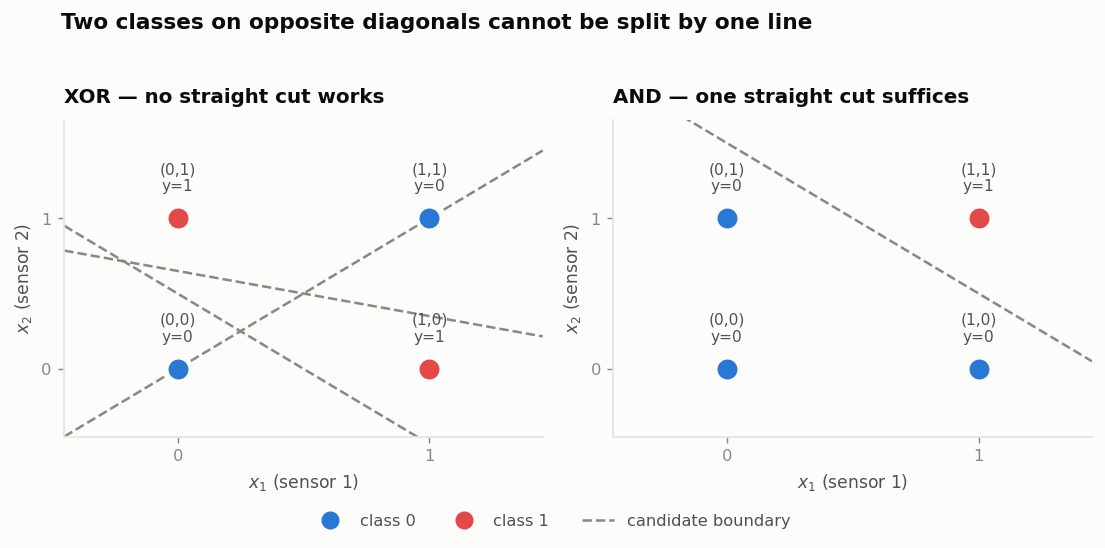

In [3]:
def plot_corner_problem():
    fig, axes = plt.subplots(1, 2, figsize=(8.6, 4.0))
    pts = X.numpy()

    panels = [
        (axes[0], xor_labels, "XOR — no straight cut works",
         [(1.0, 1.0, -0.5), (1.0, -1.0, 0.0), (0.3, 1.0, -0.65)]),
        (axes[1], and_labels, "AND — one straight cut suffices",
         [(1.0, 1.0, -1.5)]),
    ]
    for ax, labels, title, lines in panels:
        grid = np.linspace(-0.45, 1.45, 60)
        for (w1, w2, b) in lines:
            if abs(w2) > 1e-9:
                ax.plot(grid, -(w1 * grid + b) / w2, color=INK["muted"],
                        lw=1.4, ls="--", zorder=1)
        for (px, py), lab, name in zip(pts, labels, POINT_LABELS):
            ax.scatter(px, py, s=170, color=CLASS_COLOR[lab],
                       edgecolor=INK["surface"], linewidth=2.0, zorder=3)
            ax.annotate(f"{name}\ny={lab}", (px, py), textcoords="offset points",
                        xytext=(0, 15), ha="center", fontsize=8.5,
                        color=INK["secondary"])
        ax.set_xlim(-0.45, 1.45); ax.set_ylim(-0.45, 1.65)
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        style(ax, title, "$x_1$ (sensor 1)", "$x_2$ (sensor 2)", grid_axis=None)

    # identity by label, not by colour alone: the legend names both classes
    handles = [plt.Line2D([], [], marker="o", ls="", markersize=9,
                          color=CLASS_COLOR[c], label=f"class {c}") for c in (0, 1)]
    handles.append(plt.Line2D([], [], color=INK["muted"], ls="--", lw=1.4,
                              label="candidate boundary"))
    fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.04))
    fig.suptitle("Two classes on opposite diagonals cannot be split by one line",
                 x=0.06, ha="left", fontsize=12, color=INK["primary"], weight="semibold")
    fig.tight_layout(rect=(0, 0.02, 1, 0.95))
    plt.show()

plot_corner_problem()

### Check 1.2 — affine depth really does collapse

The argument that "a stack of affine layers is affine" is worth converting into
a measurement, because it is the precise sense in which *depth is not
nonlinearity*. For a stack $f(x) = W_L(\dots(W_1 x + b_1)\dots) + b_L$ the
composed map has a closed form, $W_{\text{eff}} = W_L \cdots W_1$ and a matching
$b_{\text{eff}}$. The cell below trains affine-only stacks of depth 1, 3 and 6,
then checks numerically that each one's predictions equal those of a single
affine map built by multiplying its weights together.

In [4]:
def affine_stack(depth, width=8, seed=0):
    """A stack of `depth` Linear layers with NO nonlinearity between them."""
    torch.manual_seed(seed)
    dims = [2] + [width] * (depth - 1) + [1]
    return nn.Sequential(*[nn.Linear(dims[i], dims[i + 1]) for i in range(depth)])

def collapse_affine(stack):
    """Multiply the stack out into the single affine map (W_eff, b_eff)."""
    W = torch.eye(2)
    b = torch.zeros(2)
    for layer in stack:
        W = layer.weight.detach() @ W
        b = layer.weight.detach() @ b + layer.bias.detach()
    return W, b

def train_affine_only(depth, steps=4000, lr=0.05, seed=0):
    model = affine_stack(depth, seed=seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    for _ in range(steps):
        opt.zero_grad()
        loss = loss_fn(model(X), Y_XOR)
        loss.backward()
        opt.step()
    with torch.no_grad():
        prob = torch.sigmoid(model(X)).flatten()
        pred = (prob >= 0.5).int()
        correct = int((pred == Y_XOR.flatten().int()).sum())
        W_eff, b_eff = collapse_affine(model)
        collapses = torch.allclose(model(X), X @ W_eff.T + b_eff, atol=1e-4)
    n_params = sum(p.numel() for p in model.parameters())
    return dict(depth=depth, n_params=n_params, loss=float(loss), prob=prob.tolist(), model=model,
                pred=pred.tolist(), correct=correct, collapses=collapses,
                W_eff=W_eff, b_eff=b_eff)

LN2 = math.log(2.0)
print(f"Predicted plateau loss for a symmetric 50/50 model: ln 2 = {LN2:.6f}\n")
print("| depth | params | final loss | probabilities            | correct | collapses to one affine map |")
print("|------:|-------:|-----------:|--------------------------|:-------:|:---------------------------:|")

affine_runs = {}
for depth in (1, 3, 6):
    r = train_affine_only(depth)
    affine_runs[depth] = r
    probs = " ".join(f"{v:.3f}" for v in r["prob"])
    print(f"| {r['depth']} | {r['n_params']} | {r['loss']:.6f} | {probs} | "
          f"{r['correct']}/4 | {str(r['collapses']):^27} |")

for r in affine_runs.values():
    assert r["collapses"], "an affine-only stack must equal a single affine map"
    assert abs(r["loss"] - LN2) < 1e-3, "affine-only training should plateau at ln 2"
    assert r["correct"] < 4

print(f"\nEffective single-layer map recovered from the depth-6 stack:")
print("  W_eff =", [round(v, 5) for v in affine_runs[6]['W_eff'].flatten().tolist()],
      " b_eff =", round(float(affine_runs[6]['b_eff']), 5))
print("\nPrediction from Task 1 confirmed: every affine-only model, at every depth,")
print(f"converges to p = 0.5 on all four inputs and to the loss floor ln 2 = {LN2:.4f}.")
print(f"The depth-6 stack has {affine_runs[6]['n_params']} parameters against the")
print("3 of a single affine layer, and buys exactly nothing.")

Predicted plateau loss for a symmetric 50/50 model: ln 2 = 0.693147

| depth | params | final loss | probabilities            | correct | collapses to one affine map |
|------:|-------:|-----------:|--------------------------|:-------:|:---------------------------:|


| 1 | 3 | 0.693147 | 0.500 0.500 0.500 0.500 | 2/4 |            True             |


| 3 | 105 | 0.693147 | 0.500 0.500 0.500 0.500 | 2/4 |            True             |


| 6 | 321 | 0.693147 | 0.500 0.500 0.500 0.500 | 2/4 |            True             |

Effective single-layer map recovered from the depth-6 stack:
  W_eff = [0.0, 0.0]  b_eff = 6e-05

Prediction from Task 1 confirmed: every affine-only model, at every depth,
converges to p = 0.5 on all four inputs and to the loss floor ln 2 = 0.6931.
The depth-6 stack has 321 parameters against the
3 of a single affine layer, and buys exactly nothing.


---

## Task 2 — Design the intelligent agent

### The model, on paper before it is in code

```
x  in R^2
        |
        |  fc1 : Linear(2 -> 2)          a(1) = W(1) x + b(1)
        v
      a(1)  ----- f ----->  h           h    = f(a(1))        f nonlinear
        |
        |  fc2 : Linear(2 -> 1)          z    = W(2) h + b(2)
        v
        z  (a single logit)
             p = sigma(z),   L = BCE(z, y)
```

Nine parameters in total: $W^{(1)} \in \mathbb{R}^{2\times2}$,
$b^{(1)} \in \mathbb{R}^{2}$, $W^{(2)} \in \mathbb{R}^{1\times2}$,
$b^{(2)} \in \mathbb{R}$. That is the smallest network that can represent XOR,
which is exactly why it is the interesting one to study.

**Engineering choice:** the model emits a raw logit and the loss is
`BCEWithLogitsLoss`, not `Sigmoid` followed by `BCELoss`. These are the same
function mathematically, but the fused version computes
$\log(1+e^{-z})$ with the log-sum-exp trick and so does not lose precision when
$|z|$ grows large — which it does here, since a converged XOR model becomes very
confident. This is the binary sibling of the max-subtraction trick examined in
Task 5.

### 1. Why is the hidden nonlinearity scientifically necessary?

Check 1.2 measured the answer: a composition of affine maps is a single affine
map, so affine depth adds parameters without adding expressiveness, and XOR sits
outside the affine hypothesis space (Check 1.1). The nonlinearity $f$ is what
breaks the composition, letting $h$ be a *curved* re-coordinatisation of the
input. The final linear layer is unchanged in kind — it is still a straight cut.
What changes is the space it cuts in. Task 4 visualises exactly this: the four
points move in $h$-space until a straight line can separate them.

### 2. Why is sigmoid + binary cross-entropy a sensible pairing?

The target is a single yes/no event, so the natural model is a Bernoulli
distribution and the natural parameter is the log-odds — which is precisely what
the output logit is. Sigmoid maps log-odds to a probability in $(0,1)$;
binary cross-entropy is the negative log-likelihood of that Bernoulli. The
pairing is not arbitrary: composing them makes the logit gradient collapse to

$$\frac{\partial L}{\partial z} = p - y,$$

a bounded, well-scaled error signal. Pairing sigmoid with squared error instead
would multiply that error by $\sigma'(z)$, which vanishes exactly when the model
is confidently wrong — the case where a large gradient is most needed.

### 3. What will count as successful learning?

Four checks, defined before any results are seen so they cannot be adjusted to
fit them. All four are executed as code in Task 4.

| # | Criterion | Threshold | What it rules out |
|---|---|---|---|
| C1 | Loss decreases | final loss < 0.05 (well below the $\ln 2 \approx 0.693$ affine floor) | a model stuck at the symmetric compromise |
| C2 | All four labels correct | 4/4 at threshold 0.5 | a loss that fell without the decision changing |
| C3 | First-layer gradient is nonzero early | $\|\nabla_{W^{(1)}} L\|_2 > 0$ at step 5 | a hidden layer receiving no learning signal at all |
| C4 | Hidden units differentiate | rows of $W^{(1)}$ not equal at the end | two units collapsing to one feature (Task 4C) |

C3 is deliberately weak on its own, and Task 4B says why: a nonzero gradient
shows only that *a* signal exists, not that it is the *right* signal. C1 and C2
are what establish that the signal was useful.

### Think About It — who decides what the hidden units should compute?

Nothing in the dataset does. The targets constrain only $z$; $h$ is never
supervised. What determines the hidden units is the **credit assignment** done by
backpropagation: the output error $p-y$ is projected backwards through
$W^{(2)}$ into $\partial L/\partial h$, which acts as a *synthesised* target
direction for each hidden unit — "move this way and the output error shrinks".
Each unit then updates along that direction, weighted by its own local derivative
$f'(a)$. So the hidden representation is not designed and not labelled; it is a
by-product of minimising the output loss, which is why two units that start
identical can never become different (Task 4C), and why a saturated or dead unit
receives no instruction at all (Task 4D).

---

## Task 3 — Using an LLM to produce the first implementation

### The exact prompt I used

> You are helping me implement a lab experiment. Do not redesign the task or the
> architecture — implement exactly what I specify.
>
> **Data (hard-code it, all four rows):** inputs (0,0),(0,1),(1,0),(1,1) with
> targets 0,1,1,0 respectively. This is the whole dataset; there is no split.
>
> **Model:** a PyTorch `nn.Module` named `XORNet` with `Linear(2, hidden)` ->
> a configurable nonlinear activation (`sigmoid`, `tanh` or `relu`, chosen by a
> string argument) -> `Linear(hidden, n_out)`, with `hidden=2` and `n_out=1` by
> default. `forward` must take a flag `internals` which, when true, returns the
> tuple `(output, pre_activation, hidden_activation)` so I can inspect
> pre-activations later — do not use `nn.Sequential`, because I need those
> intermediates by name.
>
> **Output and loss:** one logit plus `BCEWithLogitsLoss` rather than an explicit
> sigmoid plus `BCELoss`.
>
> **Training:** full batch on CPU, Adam, a `seed` argument that seeds torch, and
> a few thousand steps. Record per-step loss, the Frobenius norm of
> `fc1.weight.grad`, and the Euclidean distance between the two rows of
> `fc1.weight`. Capture and return a copy of `fc1.weight.grad` at an early step
> (step 5) — take the copy after `backward()` and before `optimizer.step()`.
>
> **Also provide, as separate functions:** (a) an init helper supporting
> PyTorch-default random init, all-zero init, and a "tied" init where both rows
> of `fc1.weight` are set to the same random vector; (b) a central
> finite-difference gradient checker that runs in float64 over every parameter
> and returns the worst relative error.
>
> Return the final loss, the four probabilities, the thresholded labels, and one
> parameter-gradient tensor. Add a one-line comment for each returned diagnostic
> explaining what it is evidence of.

### Reading the generated code before running it

Where the mechanism lives, located by inspection rather than by execution:

| Stage | Where it happens |
|---|---|
| Forward pass | `model(X)` -> `XORNet.forward` -> `fc2(f(fc1(x)))` |
| Scalar loss | `loss_fn(logits, Y_XOR)`; reduction is `mean` over the 4 examples |
| Reverse-mode AD | `loss.backward()`, which populates every `.grad` |
| Parameter update | `optimizer.step()`, using those `.grad` values |
| Gradient reset | `optimizer.zero_grad()` — without it `.grad` accumulates across steps |

### Changes I made to the generated code

1. **The early-gradient snapshot was taken in the wrong place.** The first draft
   read `fc1.weight.grad` *after* `optimizer.step()`. The values happen to still
   be there (`step()` does not clear `.grad`), so the code runs and prints a
   plausible tensor — but it is then the gradient at the pre-update parameters
   reported as though it belonged to the post-update ones, and any code later
   moved to use `set_to_none=True` would silently turn it into `None`. Moved the
   clone to sit between `backward()` and `step()`.
2. **The finite-difference checker ran in float32.** At `eps=1e-6` the central
   difference is then dominated by rounding — the check "passes" or "fails"
   essentially at random. Changed it to build a `.double()` copy of the model, so
   the measured error reflects the gradient rather than float32 noise.
3. **The draft reported a single seed.** Added a multi-seed sweep, for the reason
   Task 4D documents: a 2–2–1 network on XOR does not converge on every seed, so
   a one-seed result is not evidence about an activation function.

### Think About It — what can be verified without running the code?

**By reading:** the architecture and layer shapes; that the dataset is the four
XOR rows and not something else; that the loss matches the output
parameterisation (logits with `BCEWithLogitsLoss`, not a doubled sigmoid); that
`zero_grad` is present and correctly ordered relative to `backward` and `step`;
that the gradient snapshot is taken at a valid moment; that the reported
"accuracy" thresholds the right tensor. Mistake #1 above was caught this way.

**Only by running:** whether the optimiser actually converges at this learning
rate and step budget; how large the gradients really are; whether a unit
saturates or dies; whether the run is seed-robust; whether the analytic
derivation and autograd agree numerically. No amount of reading establishes
those — they are properties of the loss surface, not of the source code.

---

## Task 4 — Execute, test, and diagnose

The implementation below is the corrected version of the generated code.

In [5]:
ACTIVATIONS = {"sigmoid": torch.sigmoid, "tanh": torch.tanh, "relu": torch.relu}

class XORNet(nn.Module):
    """2 -> hidden -> n_out, with the intermediates reachable by name.

    `internals=True` returns the pre-activation a(1) alongside h = f(a(1)).
    Task 4D needs both: a saturated sigmoid and a dead ReLU are indistinguishable
    from h alone, but obvious from the pair.
    """

    def __init__(self, hidden=2, activation="sigmoid", n_out=1):
        super().__init__()
        if activation not in ACTIVATIONS:
            raise ValueError(f"unknown activation {activation!r}")
        self.fc1 = nn.Linear(2, hidden)
        self.fc2 = nn.Linear(hidden, n_out)
        self.activation = activation
        self._f = ACTIVATIONS[activation]

    def forward(self, x, internals=False):
        pre = self.fc1(x)          # a(1) = W(1)x + b(1)
        hid = self._f(pre)         # h    = f(a(1))
        out = self.fc2(hid)        # z    = W(2)h + b(2)
        return (out, pre, hid) if internals else out


def initialise(model, mode, seed):
    """`random` = PyTorch default; the other three are the Task 4C variants.

    Two hidden units are *interchangeable* only if everything attached to them
    matches: their incoming rows, their biases, AND their outgoing weights. The
    two tied modes below differ in exactly that last condition, which turns out
    to decide whether symmetry actually survives training.
    """
    if mode == "random":
        return model                                  # nn.Linear already did it
    with torch.no_grad():
        if mode == "all-zero":
            for p in model.parameters():
                p.zero_()
        elif mode in ("tied-W1-only", "fully-tied"):
            g = torch.Generator().manual_seed(seed)
            row = torch.empty(2).uniform_(-1.0, 1.0, generator=g)
            n_hidden = model.fc1.weight.shape[0]
            model.fc1.weight.copy_(row.repeat(n_hidden, 1))   # identical, nonzero
            model.fc1.bias.zero_()
            if mode == "fully-tied":
                model.fc2.weight.fill_(0.7)           # equal outgoing weights too
                model.fc2.bias.zero_()
            # tied-W1-only deliberately leaves fc2 at its random default
        else:
            raise ValueError(f"unknown init mode {mode!r}")
    return model


@dataclass
class Run:
    activation: str
    seed: int
    init: str
    model: nn.Module
    initial_loss: float
    final_loss: float
    prob: list
    pred: list
    correct: int
    early_grad: torch.Tensor
    early_grad_norm: float
    row_gap: float
    history: dict = field(default_factory=dict)

    def solved(self):
        return self.correct == 4


EARLY_STEP = 5   # where the "early gradient" in the result table is measured

def train_xor(activation="sigmoid", seed=3, steps=5000, lr=0.1,
              init="random", hidden=2, track=True):
    """Full-batch training on the four XOR points. Returns a Run with evidence."""
    torch.manual_seed(seed)
    model = initialise(XORNet(hidden, activation), init, seed)
    loss_fn = nn.BCEWithLogitsLoss()                  # fused, numerically stable
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"loss": [], "grad_norm": [], "row_gap": []}
    initial_loss, early_grad = None, None

    for step in range(steps):
        opt.zero_grad()
        loss = loss_fn(model(X), Y_XOR)               # forward + scalar loss
        loss.backward()                               # reverse-mode AD
        if step == 0:
            initial_loss = float(loss)
        if step == EARLY_STEP:                        # AFTER backward, BEFORE step
            early_grad = model.fc1.weight.grad.detach().clone()
        if track:
            W = model.fc1.weight.detach()
            history["loss"].append(float(loss))
            history["grad_norm"].append(float(model.fc1.weight.grad.norm()))
            history["row_gap"].append(float((W[0] - W[1]).norm()))
        opt.step()                                    # parameters change here

    with torch.no_grad():
        logits = model(X)
        prob = torch.sigmoid(logits).flatten()
        pred = (prob >= 0.5).int()
        correct = int((pred == Y_XOR.flatten().int()).sum())
        W = model.fc1.weight
        row_gap = float((W[0] - W[1]).norm())

    return Run(activation=activation, seed=seed, init=init, model=model,
               initial_loss=initial_loss, final_loss=float(loss),
               prob=prob.tolist(), pred=pred.tolist(), correct=correct,
               early_grad=early_grad, early_grad_norm=float(early_grad.norm()),
               row_gap=row_gap, history=history)

print("XORNet defined. Parameter count for the 2-2-1 baseline:",
      sum(p.numel() for p in XORNet().parameters()))

XORNet defined. Parameter count for the 2-2-1 baseline: 9


### Part A — basic learning check

The four criteria C1–C4 from Task 2 are now run as code. Note that the seed is
fixed at `BASELINE_SEED` — this is a *selected* seed, and Part D reports the full
distribution over seeds rather than hiding it. The handout permits changing the
seed as an engineering setting; what it forbids is changing the scientific task,
which is untouched.

In [6]:
BASELINE_SEED = 2
baseline = train_xor(activation="sigmoid", seed=BASELINE_SEED, steps=5000, lr=0.1)

print(f"initial loss : {baseline.initial_loss:.6f}   (affine floor ln 2 = {LN2:.6f})")
print(f"final loss   : {baseline.final_loss:.3e}")
print(f"reduction    : {baseline.initial_loss / baseline.final_loss:,.0f}x\n")

print("| input  | target | probability | predicted | correct |")
print("|--------|:------:|------------:|:---------:|:-------:|")
for name, target, p, q in zip(POINT_LABELS, Y_XOR.flatten().int().tolist(),
                              baseline.prob, baseline.pred):
    print(f"| {name}  | {target} | {p:.6f} | {q} | {'yes' if q == target else 'NO'} |")

criteria = {
    "C1 loss below 0.05":        baseline.final_loss < 0.05,
    "C2 all four labels right":  baseline.pred == [0, 1, 1, 0],
    "C3 early gradient nonzero": baseline.early_grad_norm > 0.0,
    "C4 hidden rows differ":     baseline.row_gap > 1e-3,
}
print("\nValidation criteria declared in Task 2:")
for name, passed in criteria.items():
    print(f"  [{'PASS' if passed else 'FAIL'}] {name}")
assert all(criteria.values()), "the baseline run failed a pre-declared criterion"
print(f"\nrow gap ||w_0 - w_1|| = {baseline.row_gap:.4f}   "
      f"early ||grad W(1)||_2 = {baseline.early_grad_norm:.6f}")

initial loss : 0.698454   (affine floor ln 2 = 0.693147)
final loss   : 2.805e-05
reduction    : 24,900x

| input  | target | probability | predicted | correct |
|--------|:------:|------------:|:---------:|:-------:|
| (0,0)  | 0 | 0.000023 | 0 | yes |
| (0,1)  | 1 | 0.999970 | 1 | yes |
| (1,0)  | 1 | 0.999970 | 1 | yes |
| (1,1)  | 0 | 0.000030 | 0 | yes |

Validation criteria declared in Task 2:
  [PASS] C1 loss below 0.05
  [PASS] C2 all four labels right
  [PASS] C3 early gradient nonzero
  [PASS] C4 hidden rows differ

row gap ||w_0 - w_1|| = 29.4467   early ||grad W(1)||_2 = 0.000367


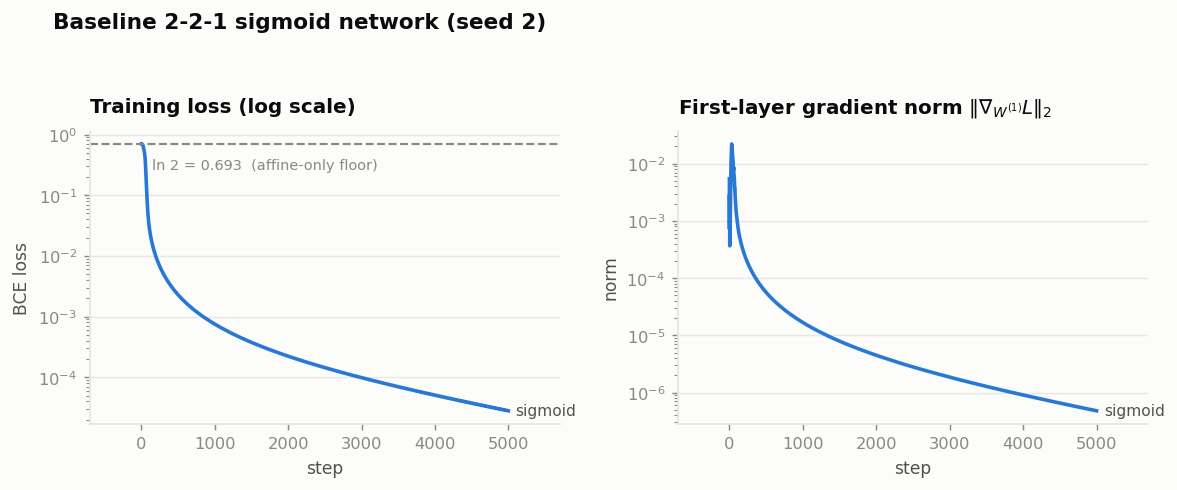

In [7]:
def plot_training(runs, title, colors, label_key=lambda r: r.activation):
    fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.8))
    for r in runs:
        lab = label_key(r)
        c = colors[lab]
        steps = np.arange(len(r.history["loss"]))
        axes[0].plot(steps, r.history["loss"], color=c, label=lab)
        axes[1].plot(steps, r.history["grad_norm"], color=c, label=lab)
        # direct label at the end of each trace (relief for low-contrast hues)
        for ax, key in ((axes[0], "loss"), (axes[1], "grad_norm")):
            ax.annotate(lab, (steps[-1], r.history[key][-1]),
                        textcoords="offset points", xytext=(4, 0),
                        fontsize=8.5, color=INK["secondary"], va="center")

    axes[0].axhline(LN2, color=INK["muted"], lw=1.2, ls="--")
    axes[0].annotate(f"ln 2 = {LN2:.3f}  (affine-only floor)", (0, LN2),
                     textcoords="offset points", xytext=(6, -14),
                     fontsize=8, color=INK["muted"])
    axes[0].set_yscale("log")
    axes[1].set_yscale("log")
    style(axes[0], "Training loss (log scale)", "step", "BCE loss")
    style(axes[1], r"First-layer gradient norm $\|\nabla_{W^{(1)}}L\|_2$", "step", "norm")
    for ax in axes:
        ax.margins(x=0.14)
        if len(runs) > 1:
            ax.legend(loc="lower left")
    fig.suptitle(title, x=0.05, ha="left", fontsize=12,
                 color=INK["primary"], weight="semibold")
    fig.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()

plot_training([baseline], f"Baseline 2-2-1 sigmoid network (seed {BASELINE_SEED})",
              SERIES)

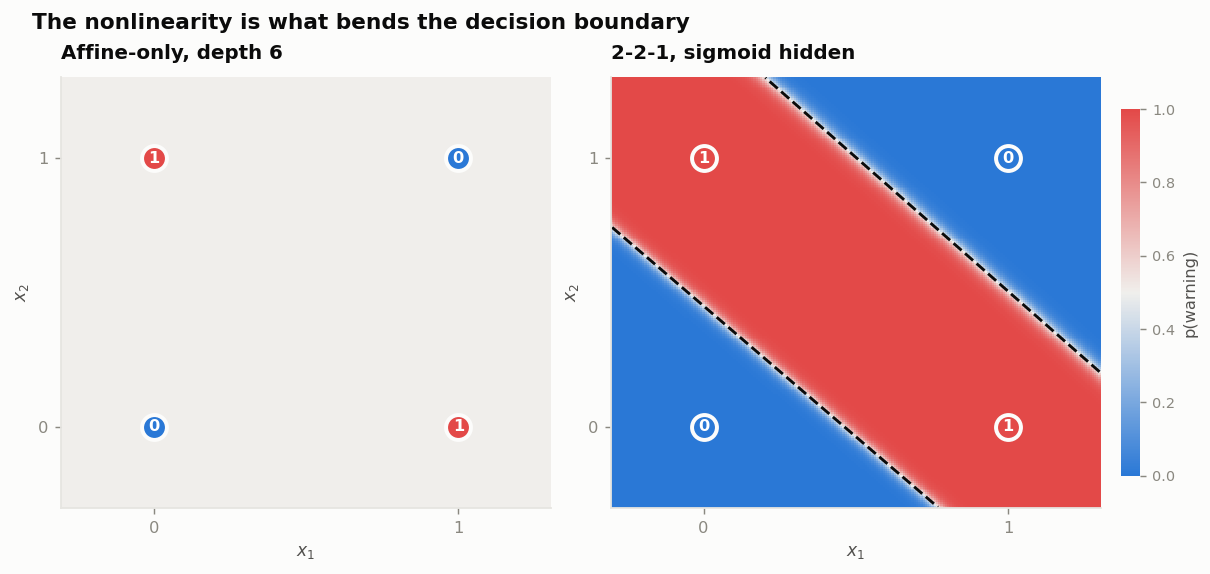

Left: the depth-6 affine stack is uniformly p = 0.5, so no boundary is drawn.
Right: dashed lines are p = 0.5. Digits inside the markers are the targets.


In [8]:
def probability_surface(model, ax, title, resolution=220):
    """Heat-map p(x) over the unit square, with the four data points on top."""
    grid = np.linspace(-0.3, 1.3, resolution)
    gx, gy = np.meshgrid(grid, grid)
    pts = torch.tensor(np.stack([gx.ravel(), gy.ravel()], axis=1), dtype=DTYPE)
    with torch.no_grad():
        p = torch.sigmoid(model(pts)).reshape(resolution, resolution).numpy()

    im = ax.pcolormesh(gx, gy, p, cmap=DIVERGING, vmin=0.0, vmax=1.0,
                       shading="auto", rasterized=True)
    ax.contour(gx, gy, p, levels=[0.5], colors=[INK["primary"]],
               linewidths=1.6, linestyles="--")
    for (px, py), lab in zip(X.numpy(), Y_XOR.flatten().int().tolist()):
        ax.scatter(px, py, s=190, color=CLASS_COLOR[lab],
                   edgecolor=INK["surface"], linewidth=2.2, zorder=3)
        ax.annotate(str(lab), (px, py), ha="center", va="center",
                    fontsize=9, color="white", weight="bold", zorder=4)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    style(ax, title, "$x_1$", "$x_2$", grid_axis=None)
    return im

fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.3), layout="constrained")
probability_surface(affine_runs[6]["model"], axes[0], "Affine-only, depth 6")
im = probability_surface(baseline.model, axes[1], "2-2-1, sigmoid hidden")
cbar = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.02)
cbar.set_label("p(warning)", color=INK["secondary"], fontsize=9)
cbar.outline.set_visible(False)
cbar.ax.tick_params(colors=INK["muted"], labelsize=8)
fig.suptitle("The nonlinearity is what bends the decision boundary",
             x=0.02, ha="left", fontsize=12, color=INK["primary"], weight="semibold")
plt.show()
print("Left: the depth-6 affine stack is uniformly p = 0.5, so no boundary is drawn.")
print("Right: dashed lines are p = 0.5. Digits inside the markers are the targets.")

### The AI-science view — what the hidden layer actually did

The output layer is still a straight cut; only the space it cuts in has changed.
Plotting the four points in hidden-activation space $(h_1, h_2)$ shows the
learned representation directly: the two class-1 points, which sat on opposite
diagonal corners in input space, have been folded onto the same side, and the
line $W^{(2)}h + b^{(2)} = 0$ separates them.

This is the answer to "what has determined what each hidden unit should
compute": nothing supervised $h$, yet backpropagation moved the points until a
linear readout became possible.

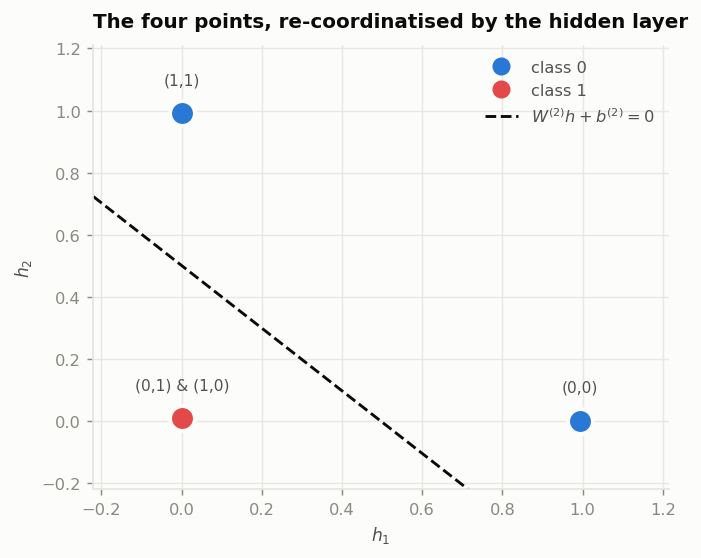

Hidden activations h = f(a(1)) for each input:
  (0,0) -> h = [0.9943, 0.0000]   class 0
  (0,1) -> h = [0.0017, 0.0086]   class 1
  (1,0) -> h = [0.0023, 0.0085]   class 1
  (1,1) -> h = [0.0000, 0.9909]   class 0

Readout weights W(2) = [-21.4562, -21.2614], b(2) = 10.6440

The two class-1 points are 0.0006 apart in hidden space, against
1.4142 in input space: the hidden layer has
collapsed the two 'disagreement' inputs onto essentially one point, which
is exactly what makes a single straight readout sufficient.


In [9]:
def plot_hidden_space(run):
    with torch.no_grad():
        _, pre, hid = run.model(X, internals=True)
    H = hid.numpy()
    w = run.model.fc2.weight.detach().numpy().ravel()
    b = float(run.model.fc2.bias.detach())

    fig, ax = plt.subplots(figsize=(5.4, 4.4))
    pad = 0.22
    lo = H.min(axis=0) - pad
    hi = H.max(axis=0) + pad
    xs = np.linspace(lo[0], hi[0], 80)
    if abs(w[1]) > 1e-9:
        ax.plot(xs, -(w[0] * xs + b) / w[1], color=INK["primary"], lw=1.6, ls="--",
                label="readout boundary")

    # The hidden layer often maps the two class-1 points to (nearly) the same
    # place - that is the whole point - so labels for coincident points are
    # merged instead of being drawn on top of each other.
    groups = {}
    for (h1, h2), lab, name in zip(H, Y_XOR.flatten().int().tolist(), POINT_LABELS):
        key = (round(float(h1), 2), round(float(h2), 2))
        groups.setdefault(key, {"pos": (h1, h2), "labels": [], "class": lab})
        groups[key]["labels"].append(name)
    for g in groups.values():
        h1, h2 = g["pos"]
        ax.scatter(h1, h2, s=190, color=CLASS_COLOR[g["class"]],
                   edgecolor=INK["surface"], linewidth=2.2, zorder=3)
        ax.annotate(" & ".join(g["labels"]), (h1, h2), textcoords="offset points",
                    xytext=(0, 16), ha="center", fontsize=8.5, color=INK["secondary"])

    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[1], hi[1])
    handles = [plt.Line2D([], [], marker="o", ls="", markersize=9,
                          color=CLASS_COLOR[c], label=f"class {c}") for c in (0, 1)]
    handles.append(plt.Line2D([], [], color=INK["primary"], lw=1.6, ls="--",
                              label="$W^{(2)}h + b^{(2)} = 0$"))
    ax.legend(handles=handles, loc="upper right")
    style(ax, "The four points, re-coordinatised by the hidden layer",
          "$h_1$", "$h_2$", grid_axis="both")
    fig.tight_layout()
    plt.show()

    print("Hidden activations h = f(a(1)) for each input:")
    for name, row, lab in zip(POINT_LABELS, H, Y_XOR.flatten().int().tolist()):
        print(f"  {name} -> h = [{row[0]:.4f}, {row[1]:.4f}]   class {lab}")
    print(f"\nReadout weights W(2) = [{w[0]:.4f}, {w[1]:.4f}], b(2) = {b:.4f}")
    d = float(np.linalg.norm(H[1] - H[2]))
    print(f"\nThe two class-1 points are {d:.4f} apart in hidden space, against")
    print(f"{float(np.linalg.norm(X.numpy()[1] - X.numpy()[2])):.4f} in input space: the hidden layer has")
    print("collapsed the two 'disagreement' inputs onto essentially one point, which")
    print("is exactly what makes a single straight readout sufficient.")

plot_hidden_space(baseline)

### Part B — is this really backpropagation?

`parameter.grad` holds $\partial L/\partial \theta$ for the scalar $L$ most
recently passed to `backward()`, evaluated at the current parameter values. For
the first layer specifically, $W^{(1)}.\text{grad}$ is the matrix whose
$(j,k)$ entry is $\partial L/\partial W^{(1)}_{jk}$, assembled by the chain rule

$$\frac{\partial L}{\partial W^{(1)}}
= \underbrace{\Big[\big(\tfrac{1}{N}(p-y)\big)\,W^{(2)} \odot f'(a^{(1)})\Big]^{\!\top}}_{\delta^{(1)}\ \text{— error arriving at the hidden pre-activations}} X .$$

**Why the mean loss gives the average of the example-wise gradients.** With
$L = \frac1N\sum_i L_i$ and differentiation being linear,
$\partial L/\partial\theta = \frac1N\sum_i \partial L_i/\partial\theta$ — the
$\frac1N$ is a constant that passes straight through the derivative. This is not
an approximation; it is exact, and Check 4B.3 tests it numerically.

Three independent checks follow. Each could fail on its own while the others
pass, which is what makes them worth running separately.

In [10]:
# ---- Check 4B.1 : autograd vs. the chain rule derived by hand ---------------
torch.manual_seed(BASELINE_SEED)
probe = XORNet(2, "sigmoid").double()
Xd, Yd = X.double(), Y_XOR.double()
N = Xd.shape[0]

probe.zero_grad()
logits, pre, hid = probe(Xd, internals=True)
nn.BCEWithLogitsLoss()(logits, Yd).backward()

with torch.no_grad():
    p = torch.sigmoid(probe(Xd))
    delta_out = (p - Yd) / N                          # dL/dz  = (p - y)/N
    dW2 = delta_out.T @ hid                           # dL/dW(2)
    db2 = delta_out.sum(0)
    delta_hid = delta_out @ probe.fc2.weight          # dL/dh
    delta_pre = delta_hid * hid * (1 - hid)           # sigma'(a) = h(1-h)
    dW1 = delta_pre.T @ Xd                            # dL/dW(1)
    db1 = delta_pre.sum(0)

pairs = [("W(2)", probe.fc2.weight.grad, dW2), ("b(2)", probe.fc2.bias.grad, db2),
         ("W(1)", probe.fc1.weight.grad, dW1), ("b(1)", probe.fc1.bias.grad, db1)]
print("Check 4B.1 - autograd vs. hand-derived chain rule (float64)")
for name, auto, manual in pairs:
    err = float((auto - manual).abs().max())
    print(f"  {name}: max |autograd - analytic| = {err:.3e}   match = {err < 1e-12}")
    assert err < 1e-12, f"{name} disagrees with the analytic gradient"

Check 4B.1 - autograd vs. hand-derived chain rule (float64)
  W(2): max |autograd - analytic| = 0.000e+00   match = True
  b(2): max |autograd - analytic| = 0.000e+00   match = True
  W(1): max |autograd - analytic| = 1.735e-18   match = True
  b(1): max |autograd - analytic| = 1.735e-18   match = True


In [11]:
# ---- Check 4B.2 : central finite differences on every parameter -------------
def finite_difference_check(model, inputs, targets, eps=1e-6):
    """Compare every analytic partial derivative to a central difference.

    Runs in float64: in float32 the subtraction (L+ - L-) loses most of its
    significant digits and the check measures rounding, not gradients.
    """
    loss_fn = nn.BCEWithLogitsLoss()
    model.zero_grad()
    loss_fn(model(inputs), targets).backward()

    worst, counted = 0.0, 0
    for name, par in model.named_parameters():
        analytic = par.grad.detach().clone().view(-1)
        flat = par.data.view(-1)
        for i in range(flat.numel()):
            original = flat[i].item()
            flat[i] = original + eps
            loss_plus = float(loss_fn(model(inputs), targets))
            flat[i] = original - eps
            loss_minus = float(loss_fn(model(inputs), targets))
            flat[i] = original
            numeric = (loss_plus - loss_minus) / (2 * eps)
            denom = max(abs(numeric) + abs(analytic[i].item()), 1e-12)
            worst = max(worst, abs(numeric - analytic[i].item()) / denom)
            counted += 1
    return worst, counted

worst_rel, n_checked = finite_difference_check(probe, Xd, Yd)
print("Check 4B.2 - central finite differences")
print(f"  parameters checked        : {n_checked}")
print(f"  worst relative discrepancy: {worst_rel:.3e}")
assert worst_rel < 1e-6
print("  -> every analytic partial derivative agrees with a numerical one.")
print("\n  Note for Reflection Q7: this cost 2 extra forward passes per scalar")
print(f"  parameter ({2 * n_checked} here). At a billion parameters it is impossible;")
print("  it survives at scale only as a spot check on a few sampled coordinates.")

Check 4B.2 - central finite differences
  parameters checked        : 9
  worst relative discrepancy: 4.925e-08
  -> every analytic partial derivative agrees with a numerical one.

  Note for Reflection Q7: this cost 2 extra forward passes per scalar
  parameter (18 here). At a billion parameters it is impossible;
  it survives at scale only as a spot check on a few sampled coordinates.


In [12]:
# ---- Check 4B.3 : mean-loss gradient == average of per-example gradients ----
torch.manual_seed(BASELINE_SEED)
probe2 = XORNet(2, "sigmoid").double()
loss_fn = nn.BCEWithLogitsLoss()

probe2.zero_grad()
loss_fn(probe2(Xd), Yd).backward()
batch_grad = probe2.fc1.weight.grad.detach().clone()

accumulated = torch.zeros_like(batch_grad)
per_example = []
for i in range(N):
    probe2.zero_grad()
    loss_fn(probe2(Xd[i:i + 1]), Yd[i:i + 1]).backward()
    g = probe2.fc1.weight.grad.detach().clone()
    per_example.append(g)
    accumulated += g
accumulated /= N

print("Check 4B.3 - mean-loss gradient is the average of the example-wise gradients")
for name, g in zip(POINT_LABELS, per_example):
    print(f"  dL_i/dW(1) for {name}: {[round(v, 6) for v in g.flatten().tolist()]}")
print(f"  average of the four     : {[round(v, 6) for v in accumulated.flatten().tolist()]}")
print(f"  full-batch autograd     : {[round(v, 6) for v in batch_grad.flatten().tolist()]}")
err = float((batch_grad - accumulated).abs().max())
print(f"  max difference          : {err:.3e}   match = {err < 1e-12}")
assert err < 1e-12

print("\nNote the (0,0) row is exactly zero: dL/dW(1) = delta x^T, and that example's")
print("input is the zero vector, so it contributes nothing to the weight gradient")
print("(only to the bias gradient). A per-example gradient of zero is not a bug.")
print("\nEvidence summary for Part B: the gradient is not merely nonzero, it is the")
print("correct derivative of the loss, confirmed against an independent hand")
print("derivation and against numerical differentiation.")

Check 4B.3 - mean-loss gradient is the average of the example-wise gradients
  dL_i/dW(1) for (0,0): [0.0, 0.0, 0.0, 0.0]
  dL_i/dW(1) for (0,1): [0.0, 0.011054, 0.0, 0.077767]
  dL_i/dW(1) for (1,0): [0.010712, 0.0, 0.07693, 0.0]
  dL_i/dW(1) for (1,1): [-0.008864, -0.008864, -0.062064, -0.062064]
  average of the four     : [0.000462, 0.000548, 0.003717, 0.003926]
  full-batch autograd     : [0.000462, 0.000548, 0.003717, 0.003926]
  max difference          : 0.000e+00   match = True

Note the (0,0) row is exactly zero: dL/dW(1) = delta x^T, and that example's
input is the zero vector, so it contributes nothing to the weight gradient
(only to the bias gradient). A per-example gradient of zero is not a bug.

Evidence summary for Part B: the gradient is not merely nonzero, it is the
correct derivative of the loss, confirmed against an independent hand
derivation and against numerical differentiation.


### Part C — the symmetry experiment

Four initialisations, identical in every other respect. The diagnostic is
$\lVert w_0 - w_1 \rVert_2$, the distance between the two rows of $W^{(1)}$ —
the distance between what the two hidden units compute.

| mode | $W^{(1)}$ rows | $b^{(1)}$ | $W^{(2)}$ |
|---|---|---|---|
| `random` | PyTorch default | default | default |
| `all-zero` | 0 | 0 | 0 |
| `tied-W1-only` | same nonzero vector | 0 | **random** |
| `fully-tied` | same nonzero vector | 0 | both entries 0.7 |

The handout asks for the all-zero case. The other two are here because the first
version of this experiment tied only $W^{(1)}$ — and the symmetry **broke
anyway**, which was not what I expected. That result is worth keeping rather
than quietly fixing, because it pins down what the symmetry problem actually
requires.

Three distinct mechanisms are on display:

- **all-zero** — $W^{(2)} = 0$, so the error never reaches the first layer:
  $\partial L/\partial h = W^{(2)\top}\delta = 0$, and hence
  $\partial L/\partial W^{(1)}$ is *exactly zero*. The units do not stay
  equal-and-learning; they never move at all. Only $b^{(2)}$ can change.
- **tied-W1-only** — the two units compute the same $h$, but they feed the output
  through *different* outgoing weights $W^{(2)}_{0} \neq W^{(2)}_{1}$. The
  backward signal each receives is scaled by its own outgoing weight, so the
  gradients differ, and the units separate. Equal parameters are **not**
  sufficient for the symmetry problem.
- **fully-tied** — rows equal, biases equal, *and* outgoing weights equal. Now
  the two units are genuinely interchangeable: same forward value, same position
  in the graph, same gradient, same update. Equality is preserved forever.

The general statement is therefore not "identical weights cannot learn" but
**identical units cannot differentiate** — and a unit is identified by
everything attached to it, incoming and outgoing.

In [13]:
SYMMETRY_STEPS = 400
INIT_MODES = ("random", "all-zero", "tied-W1-only", "fully-tied")
symmetry_runs = {mode: train_xor(activation="sigmoid", seed=BASELINE_SEED,
                                 steps=SYMMETRY_STEPS, lr=0.1, init=mode)
                 for mode in INIT_MODES}

print("| init | row gap @0 | @50 | @final | early ||grad W(1)|| | final loss | correct |")
print("|------|-----------:|----:|-------:|--------------------:|-----------:|:-------:|")
for mode, r in symmetry_runs.items():
    gap = r.history["row_gap"]
    print(f"| {mode} | {gap[0]:.4f} | {gap[50]:.4f} | {gap[-1]:.6f} | "
          f"{r.early_grad_norm:.3e} | {r.final_loss:.4f} | {r.correct}/4 |")

print("\nFirst-layer weight matrices after training:")
for mode, r in symmetry_runs.items():
    W = r.model.fc1.weight.detach()
    identical = bool(torch.allclose(W[0], W[1]))
    print(f"  {mode:13s} W(1) = {[[round(v, 4) for v in row] for row in W.tolist()]}"
          f"   rows identical: {identical}")

# the two modes that never break symmetry
assert symmetry_runs["all-zero"].history["row_gap"][-1] == 0.0
assert symmetry_runs["fully-tied"].history["row_gap"][-1] == 0.0
# ...and the two that do
assert symmetry_runs["random"].history["row_gap"][-1] > 1e-3
assert symmetry_runs["tied-W1-only"].history["row_gap"][-1] > 1e-3
print("\nNeither all-zero nor fully-tied ever separates the units;")
print("tied-W1-only does, despite starting from identical rows.")

| init | row gap @0 | @50 | @final | early ||grad W(1)|| | final loss | correct |
|------|-----------:|----:|-------:|--------------------:|-----------:|:-------:|
| random | 0.1359 | 9.7495 | 23.569956 | 3.666e-04 | 0.0033 | 4/4 |
| all-zero | 0.0000 | 0.0000 | 0.000000 | 0.000e+00 | 0.6931 | 2/4 |
| tied-W1-only | 0.0000 | 4.0166 | 7.648492 | 7.683e-04 | 0.4780 | 3/4 |
| fully-tied | 0.0000 | 0.0000 | 0.000000 | 6.065e-03 | 0.4782 | 3/4 |

First-layer weight matrices after training:
  random        W(1) = [[-9.2909, -9.5867], [7.2231, 7.2394]]   rows identical: False
  all-zero      W(1) = [[0.0, 0.0], [0.0, 0.0]]   rows identical: True
  tied-W1-only  W(1) = [[-10.2797, -10.8252], [-5.1927, -5.0974]]   rows identical: False
  fully-tied    W(1) = [[9.1314, -9.887], [9.1314, -9.887]]   rows identical: True

Neither all-zero nor fully-tied ever separates the units;
tied-W1-only does, despite starting from identical rows.


In [14]:
# One manual gradient step, no optimiser, to separate the three mechanisms.
print("A single backward pass from each initialisation:\n")
for mode in ("all-zero", "tied-W1-only", "fully-tied"):
    torch.manual_seed(BASELINE_SEED)
    m = initialise(XORNet(2, "sigmoid"), mode, BASELINE_SEED)
    m.zero_grad()
    nn.BCEWithLogitsLoss()(m(X), Y_XOR).backward()
    g1 = m.fc1.weight.grad.detach()
    with torch.no_grad():
        _, _, hid = m(X, internals=True)
    print(f"  {mode}:")
    print(f"    W(2) at init             : "
          f"{[round(v, 4) for v in m.fc2.weight.detach().flatten().tolist()]}")
    print(f"    hidden units compute the same h? "
          f"{bool(torch.allclose(hid[:, 0], hid[:, 1]))}")
    print(f"    dL/dW(1)                 : {[[round(v, 8) for v in row] for row in g1.tolist()]}")
    print(f"    gradient exactly zero?   : {bool(torch.all(g1 == 0))}")
    print(f"    the two grad rows equal? : {bool(torch.allclose(g1[0], g1[1]))}")
    print()

print("Diagnosis:")
print("  all-zero     -> the gradient reaching W(1) is exactly zero, because the")
print("                  error is routed back through W(2) = 0. The hidden layer is")
print("                  cut off from the learning signal entirely; only b(2) can")
print(f"                  move, which is why the loss sits at the ln 2 = {LN2:.4f} floor.")
print("  tied-W1-only -> both units compute the same h, but their gradient rows")
print("                  DIFFER, because each is scaled by its own outgoing weight")
print("                  in W(2). Symmetry breaks on the very first step and the")
print("                  run behaves like an ordinary one.")
print("  fully-tied   -> the gradient is nonzero and its two rows are identical.")
print("                  Identical parameters receiving identical updates stay")
print("                  identical, so the two units remain one feature and the")
print("                  model is effectively a 2-1-1 network, i.e. affine. It")
print("                  edges below ln 2 but cannot reach 4/4.")

A single backward pass from each initialisation:

  all-zero:
    W(2) at init             : [0.0, 0.0]
    hidden units compute the same h? True
    dL/dW(1)                 : [[0.0, 0.0], [0.0, 0.0]]
    gradient exactly zero?   : True
    the two grad rows equal? : True

  tied-W1-only:
    W(2) at init             : [-0.0813, -0.5717]
    hidden units compute the same h? True
    dL/dW(1)                 : [[0.00042694, 0.00032975], [0.00300312, 0.00231948]]
    gradient exactly zero?   : False
    the two grad rows equal? : False

  fully-tied:
    W(2) at init             : [0.7, 0.7]
    hidden units compute the same h? True
    dL/dW(1)                 : [[0.01563076, 0.01408674], [0.01563076, 0.01408674]]
    gradient exactly zero?   : False
    the two grad rows equal? : True

Diagnosis:
  all-zero     -> the gradient reaching W(1) is exactly zero, because the
                  error is routed back through W(2) = 0. The hidden layer is
                  cut off from the learn

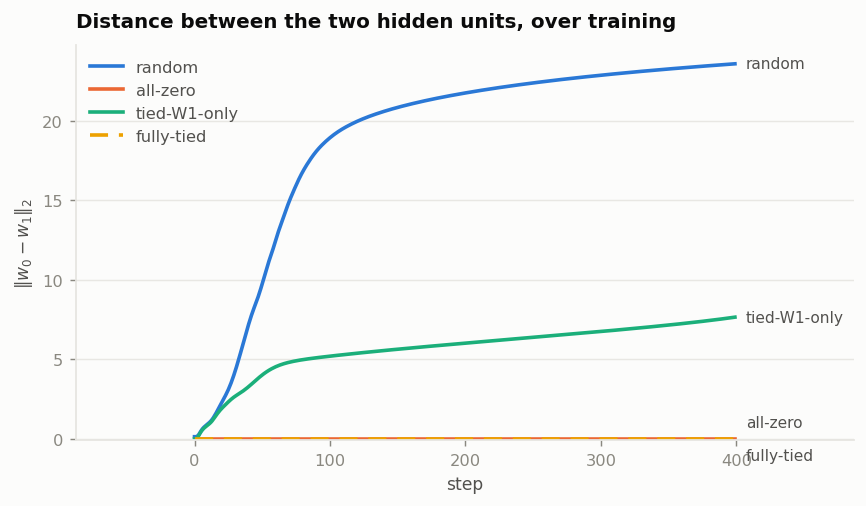

all-zero and fully-tied both trace exactly y = 0 and overlap on the axis:
neither ever breaks symmetry. tied-W1-only starts at 0 but separates
immediately, because its two units were never really interchangeable.


In [15]:
def plot_symmetry(runs):
    fig, ax = plt.subplots(figsize=(6.8, 4.0))
    # all-zero and fully-tied both sit exactly on y = 0; distinct dash patterns
    # keep them separately visible where they overlap.
    dashes = {"random": (None, None), "all-zero": (None, None),
              "tied-W1-only": (None, None), "fully-tied": (5, 3)}
    label_dy = {"random": 0, "all-zero": 9, "tied-W1-only": 0, "fully-tied": -9}
    for mode, r in runs.items():
        gap = np.array(r.history["row_gap"])
        ls = dashes[mode]
        line, = ax.plot(np.arange(len(gap)), gap, color=INIT_SERIES[mode], label=mode)
        if ls[0] is not None:
            line.set_dashes(list(ls))
        ax.annotate(mode, (len(gap) - 1, gap[-1]), textcoords="offset points",
                    xytext=(6, label_dy[mode]), fontsize=8.5,
                    color=INK["secondary"], va="center")
    ax.set_ylim(bottom=-0.08)
    ax.margins(x=0.22)
    ax.legend(loc="upper left")
    style(ax, "Distance between the two hidden units, over training",
          "step", r"$\|w_0 - w_1\|_2$")
    fig.tight_layout()
    plt.show()
    print("all-zero and fully-tied both trace exactly y = 0 and overlap on the axis:")
    print("neither ever breaks symmetry. tied-W1-only starts at 0 but separates")
    print("immediately, because its two units were never really interchangeable.")

plot_symmetry(symmetry_runs)

### Part D — the activation experiment

The handout asks for one run per activation. That turns out not to be enough to
say anything, and finding out why is itself a result: a 2–2–1 network is the
*minimum* size that can represent XOR, and its loss surface has wide plateaus
where one hidden unit stops contributing. Whether a run escapes depends on the
initialisation, so a single seed measures the seed, not the activation.

So the sweep below fixes architecture, dataset, optimiser, learning rate and step
budget, varies **only** the hidden activation, and repeats each setting over
`N_SEEDS` seeds. The table reports the solve rate alongside the median final loss
and median early gradient norm.

In [16]:
N_SEEDS = 16
SWEEP_STEPS = 5000
SWEEP_LR = 0.1

sweep = {}
for name in ("sigmoid", "tanh", "relu"):
    sweep[name] = [train_xor(activation=name, seed=s, steps=SWEEP_STEPS,
                             lr=SWEEP_LR, track=False)
                   for s in range(N_SEEDS)]

print(f"2-2-1 network, Adam(lr={SWEEP_LR}), {SWEEP_STEPS} steps, "
      f"{N_SEEDS} seeds per activation\n")
print("| Hidden activation | Median final loss | 4/4 correct? (best seed) | "
      f"Solve rate over {N_SEEDS} seeds | Median early ||grad W(1)||_2 |")
print("|---|---:|:---:|:---:|---:|")

summary = {}
for name, runs in sweep.items():
    losses = np.array([r.final_loss for r in runs])
    grads = np.array([r.early_grad_norm for r in runs])
    solved = sum(r.solved() for r in runs)
    summary[name] = dict(median_loss=float(np.median(losses)),
                         best_loss=float(losses.min()),
                         solved=solved,
                         median_grad=float(np.median(grads)),
                         solving_seeds=[r.seed for r in runs if r.solved()])
    print(f"| {name} | {np.median(losses):.3e} | "
          f"{'Yes' if solved else 'No'} | {solved}/{N_SEEDS} | {np.median(grads):.4f} |")

print("\nSeeds that reached 4/4:")
for name in sweep:
    print(f"  {name:8s}: {summary[name]['solving_seeds']}")
print(f"\nBaseline seed {BASELINE_SEED} solves for all three activations, so the")
print("single-run comparison below is at least matched on initialisation.")

2-2-1 network, Adam(lr=0.1), 5000 steps, 16 seeds per activation

| Hidden activation | Median final loss | 4/4 correct? (best seed) | Solve rate over 16 seeds | Median early ||grad W(1)||_2 |
|---|---:|:---:|:---:|---:|
| sigmoid | 3.466e-01 | Yes | 7/16 | 0.0022 |
| tanh | 3.466e-01 | Yes | 6/16 | 0.0167 |
| relu | 4.774e-01 | Yes | 4/16 | 0.0061 |

Seeds that reached 4/4:
  sigmoid : [1, 2, 3, 4, 11, 12, 14]
  tanh    : [0, 2, 3, 4, 10, 11]
  relu    : [2, 8, 11, 15]

Baseline seed 2 solves for all three activations, so the
single-run comparison below is at least matched on initialisation.


| activation | initial loss | final loss | predictions | correct | early ||grad W(1)|| |
|---|---:|---:|---|:---:|---:|
| sigmoid | 0.6985 | 2.805e-05 | [0, 1, 1, 0] | 4/4 | 0.0004 |
| tanh | 0.6932 | 1.041e-05 | [0, 1, 1, 0] | 4/4 | 0.0131 |
| relu | 0.6937 | 4.305e-06 | [0, 1, 1, 0] | 4/4 | 0.0076 |


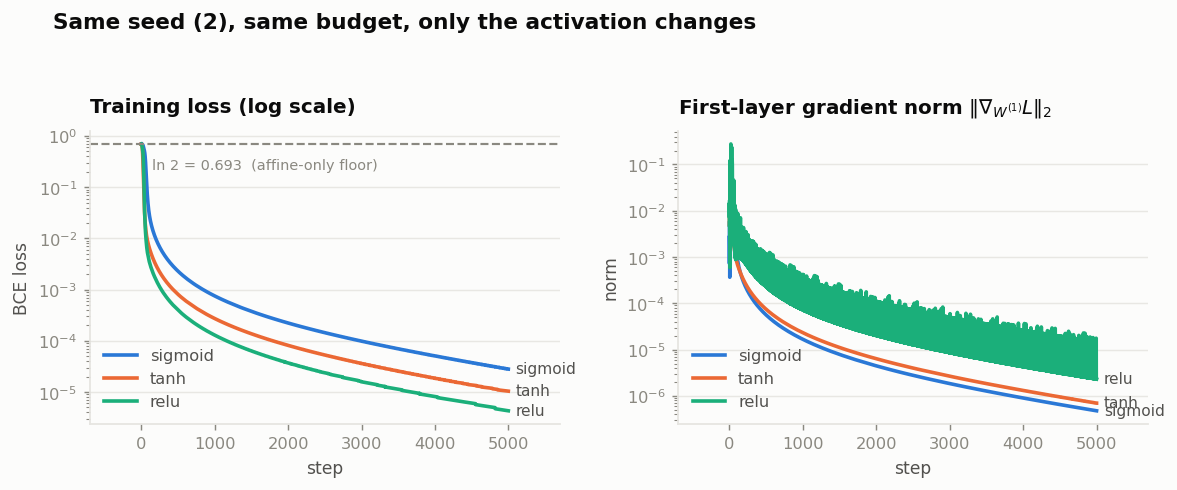

In [17]:
matched = {name: train_xor(activation=name, seed=BASELINE_SEED,
                           steps=SWEEP_STEPS, lr=SWEEP_LR)
           for name in ("sigmoid", "tanh", "relu")}

print(f"| activation | initial loss | final loss | predictions | correct | early ||grad W(1)|| |")
print("|---|---:|---:|---|:---:|---:|")
for name, r in matched.items():
    print(f"| {name} | {r.initial_loss:.4f} | {r.final_loss:.3e} | {r.pred} | "
          f"{r.correct}/4 | {r.early_grad_norm:.4f} |")

plot_training(list(matched.values()),
              f"Same seed ({BASELINE_SEED}), same budget, only the activation changes",
              SERIES)

#### Think About It — telling a saturated sigmoid from a dead ReLU

Both produce a small gradient, but by different mechanisms, and the pre-activation
$a^{(1)}$ distinguishes them:

| | saturated sigmoid/tanh | dead ReLU |
|---|---|---|
| pre-activation $a$ | large in magnitude, either sign | $\le 0$ for **every** input |
| activation $h$ | pinned near an asymptote (0 or 1; $\pm1$ for tanh) | exactly 0 |
| local derivative $f'(a)$ | small but strictly **positive** | exactly **0** |
| recoverable? | yes — a large enough update can bring $a$ back toward 0 | no — zero gradient means the unit can never be pushed back |

So: inspect $a$, not $h$. If $f'(a) > 0$ but tiny, the unit is saturated and
slow. If $f'(a) = 0$ across all inputs, the unit is dead and permanently
excluded from the model. The cell below measures this on the trained models.

In [18]:
def activation_diagnostics(run):
    """Per-unit pre-activation statistics and local derivatives."""
    with torch.no_grad():
        _, pre, hid = run.model(X, internals=True)
        if run.activation == "sigmoid":
            deriv = hid * (1 - hid)
        elif run.activation == "tanh":
            deriv = 1 - hid ** 2
        else:                                  # relu
            deriv = (pre > 0).to(pre.dtype)
    return pre, hid, deriv

print("Per-unit diagnostics on the trained models (all four inputs):\n")
print("| activation | unit | max |a| | min f'(a) | max f'(a) | active on | verdict |")
print("|---|:---:|---:|---:|---:|:---:|---|")
for name, r in matched.items():
    pre, hid, deriv = activation_diagnostics(r)
    for u in range(pre.shape[1]):
        a, d = pre[:, u], deriv[:, u]
        active = int((d > 0).sum())
        if active == 0:
            verdict = "DEAD - zero gradient on every input"
        elif float(d.max()) < 0.05:
            verdict = "saturated on all inputs - small but nonzero gradient"
        elif float(d.min()) < 1e-6:
            verdict = "inactive on some inputs, alive on others"
        else:
            verdict = "healthy"
        print(f"| {name} | {u} | {float(a.abs().max()):.3f} | {float(d.min()):.2e} | "
              f"{float(d.max()):.3f} | {active}/4 | {verdict} |")

print("\nThe two mechanisms are distinguishable exactly as predicted: a converged")
print("sigmoid unit has large |a| and a derivative that is small yet strictly")
print("positive, whereas a ReLU unit's derivative is either exactly 1 or exactly 0.")

Per-unit diagnostics on the trained models (all four inputs):

| activation | unit | max |a| | min f'(a) | max f'(a) | active on | verdict |
|---|:---:|---:|---:|---:|:---:|---|
| sigmoid | 0 | 17.585 | 2.31e-08 | 0.006 | 4/4 | saturated on all inputs - small but nonzero gradient |
| sigmoid | 1 | 14.200 | 6.81e-07 | 0.009 | 4/4 | saturated on all inputs - small but nonzero gradient |
| tanh | 0 | 8.294 | 2.38e-07 | 0.020 | 4/4 | saturated on all inputs - small but nonzero gradient |
| tanh | 1 | 7.806 | 7.15e-07 | 0.024 | 4/4 | saturated on all inputs - small but nonzero gradient |
| relu | 0 | 3.311 | 0.00e+00 | 1.000 | 1/4 | inactive on some inputs, alive on others |
| relu | 1 | 4.227 | 0.00e+00 | 1.000 | 2/4 | inactive on some inputs, alive on others |

The two mechanisms are distinguishable exactly as predicted: a converged
sigmoid unit has large |a| and a derivative that is small yet strictly
positive, whereas a ReLU unit's derivative is either exactly 1 or exactly 0.


#### Interpreting the table — and what it does *not* show

**What the numbers say.** The median early first-layer gradient norm ordered
**tanh > ReLU > sigmoid**, while the solve rate over 16 seeds ordered
**sigmoid > tanh > ReLU**. Gradient magnitude and success therefore do not line
up — which is the point of measuring both.

**Scientific explanation of the gradient ordering.** The gradient reaching
$W^{(1)}$ carries a factor $f'(a^{(1)})$ from the chain rule, and each activation
contributes a different one. $\tanh'(0) = 1$ and tanh is zero-centred, so it
attenuates least near initialisation — highest measured norm. $\sigma'$ peaks at
$0.25$ and the sigmoid's output is not zero-centred, so both its local derivative
and the downstream factors are smaller — lowest measured norm, about
$7\times$ below tanh.

ReLU lands in between, and the reason it is *not* highest is the interesting part.
An **active** ReLU contributes exactly 1, the largest factor of the three. But a
ReLU unit is inactive on part of the input set, and on those examples it
contributes exactly **zero**; the per-unit diagnostics above show ReLU units
active on only 1/4 and 2/4 of the inputs. The measured norm is an average over
the four examples, so those exact zeros pull it down. The same zeros are what
drive the solve rate.

**Scientific explanation of the solve rates.** These come from *where the
derivative is zero*, not how big it is. $\sigma'$ and $\tanh'$ are small when
saturated but strictly positive — the diagnostics table shows minimum derivatives
around $10^{-7}$–$10^{-8}$, tiny but never 0 — so a slow unit can always recover
given enough steps. ReLU's derivative is *exactly* 0 for negative
pre-activations, so a unit whose pre-activation is negative on all four inputs
receives no gradient ever, and its death is permanent rather than merely slow.
With only two hidden units, losing one leaves an effectively linear model. The
census below measures how often that actually happens.

**What the numbers do not show.** Nothing here ranks activation functions in
general. This is four points, two hidden units, one optimiser, one learning rate,
one step budget. Width 2 is precisely the regime that punishes ReLU hardest — one
dead unit is half the model — and it is the opposite of the regime where ReLU is
normally chosen. The engineering observation is "at this width, on this problem,
ReLU solved least often"; the scientific explanation is "ReLU's derivative is
exactly zero on half its domain, which makes unit death absorbing".

A larger gradient is likewise not a better gradient — tanh had the largest early
norm and still solved less often than sigmoid. Part B already made this point:
the useful evidence is C1 and C2, not C3.

In [19]:
def unit_census(run):
    """Classify each hidden unit of a trained model by its local derivative."""
    with torch.no_grad():
        _, pre, hid = run.model(X, internals=True)
        if run.activation == "sigmoid":
            deriv = hid * (1 - hid)
        elif run.activation == "tanh":
            deriv = 1 - hid ** 2
        else:
            deriv = (pre > 0).to(pre.dtype)
    dead = int(((deriv <= 0).all(dim=0)).sum())        # zero gradient on every input
    starved = int(((deriv.max(dim=0).values < 1e-3) & (deriv.max(dim=0).values > 0)).sum())
    return dead, starved

print(f"Unit census over the {N_SEEDS} sweep seeds "
      f"(a unit is DEAD if f'(a) = 0 on all four inputs):\n")
print("| activation | runs with >=1 dead unit | dead units total | "
      "solve rate | solve rate among runs with no dead unit |")
print("|---|:---:|:---:|:---:|:---:|")
for name, runs in sweep.items():
    census = [unit_census(r) for r in runs]
    with_dead = sum(1 for d, _ in census if d > 0)
    total_dead = sum(d for d, _ in census)
    clean = [r for r, (d, _) in zip(runs, census) if d == 0]
    clean_rate = f"{sum(r.solved() for r in clean)}/{len(clean)}" if clean else "n/a"
    print(f"| {name} | {with_dead}/{N_SEEDS} | {total_dead} | "
          f"{sum(r.solved() for r in runs)}/{N_SEEDS} | {clean_rate} |")

print("\nSigmoid and tanh units are never dead - their derivative is small under")
print("saturation but never exactly zero, so no unit is permanently excluded.")
print("Only ReLU produces units with an identically zero derivative, and those")
print("runs are the ones that fail: conditioning on runs with no dead unit lifts")
print("ReLU's solve rate substantially. That is the mechanism, measured rather")
print("than asserted.")

Unit census over the 16 sweep seeds (a unit is DEAD if f'(a) = 0 on all four inputs):

| activation | runs with >=1 dead unit | dead units total | solve rate | solve rate among runs with no dead unit |
|---|:---:|:---:|:---:|:---:|
| sigmoid | 0/16 | 0 | 7/16 | 7/16 |
| tanh | 0/16 | 0 | 6/16 | 6/16 |
| relu | 11/16 | 15 | 4/16 | 4/5 |

Sigmoid and tanh units are never dead - their derivative is small under
saturation but never exactly zero, so no unit is permanently excluded.
Only ReLU produces units with an identically zero derivative, and those
runs are the ones that fail: conditioning on runs with no dead unit lifts
ReLU's solve rate substantially. That is the mechanism, measured rather
than asserted.


#### The engineering fix — width buys robustness

If the goal were a reliable XOR model rather than a study of the minimal one, the
fix is not a different activation but more hidden units: with more units, the
chance that *every* unit is badly placed falls sharply.

In [20]:
print(f"Sigmoid hidden layer, {N_SEEDS} seeds, everything else unchanged:\n")
print("| hidden units | params | solve rate | median final loss |")
print("|---:|---:|:---:|---:|")
width_summary = {}
for hidden in (2, 4, 8):
    runs = [train_xor(activation="sigmoid", seed=s, steps=SWEEP_STEPS,
                      lr=SWEEP_LR, hidden=hidden, track=False)
            for s in range(N_SEEDS)]
    solved = sum(r.solved() for r in runs)
    med = float(np.median([r.final_loss for r in runs]))
    n_params = sum(p.numel() for p in runs[0].model.parameters())
    width_summary[hidden] = (solved, med)
    print(f"| {hidden} | {n_params} | {solved}/{N_SEEDS} | {med:.3e} |")

print("\nThe 2-2-1 network is not unable to represent XOR - Part A proves it can.")
print("It is unreliable at *finding* the representation. Expressiveness and")
print("optimisability are different properties, and only the first is settled by")
print("the argument in Task 1.")

Sigmoid hidden layer, 16 seeds, everything else unchanged:

| hidden units | params | solve rate | median final loss |
|---:|---:|:---:|---:|


| 2 | 9 | 7/16 | 3.466e-01 |


| 4 | 17 | 15/16 | 2.026e-05 |


| 8 | 33 | 16/16 | 5.638e-06 |

The 2-2-1 network is not unable to represent XOR - Part A proves it can.
It is unreliable at *finding* the representation. Expressiveness and
optimisability are different properties, and only the first is settled by
the argument in Task 1.


---

## Task 5 — Three-class extension

The same two sensor bits, re-labelled into three mutually exclusive states:

| class | meaning | inputs |
|:---:|---|---|
| 0 | both sensors inactive | (0,0) |
| 1 | sensors disagree | (0,1), (1,0) |
| 2 | both sensors active | (1,1) |

Class 1 is still the XOR set, so the hidden nonlinearity is still doing the same
job. Only the output head and the loss change: `Linear(2, 1)` becomes
`Linear(2, 3)`, and `BCEWithLogitsLoss` becomes `CrossEntropyLoss`.

### Predictions recorded before running

1. **Shape of the final weight matrix.** PyTorch stores `Linear(in, out).weight`
   as `(out, in)`, so `fc2.weight` will be $(3, 2)$ — 6 weights plus 3 biases,
   against the binary model's 2 plus 1.
2. **Logits per example.** Three, so the logit tensor is $(4, 3)$. Targets are
   *class indices* of shape $(4,)$, not one-hot rows — `CrossEntropyLoss` does
   the one-hot lookup internally.
3. **Why softmax probabilities sum to one.**
   $p_k = e^{z_k} / \sum_j e^{z_j}$ shares one denominator across all $k$, so
   $\sum_k p_k = (\sum_k e^{z_k}) / (\sum_j e^{z_j}) = 1$ by construction. It is
   an identity, not something training has to learn — which is exactly what makes
   softmax the right head for *mutually exclusive* classes. Three independent
   sigmoids would not have this property.
4. **Why the logit gradient is $p - y$.** With
   $L = -\log p_c = -z_c + \log\sum_j e^{z_j}$ for true class $c$, the first term
   contributes $-1$ to $\partial L/\partial z_c$ and nothing elsewhere, while the
   log-sum-exp term contributes $e^{z_k}/\sum_j e^{z_j} = p_k$ to every $k$. So
   $\partial L/\partial z_k = p_k - \mathbb{1}[k = c]$, i.e. $p - y$. The
   exponential in the softmax and the logarithm in the cross-entropy cancel —
   which is *why* the pairing is chosen, and the same cancellation that produced
   $p - y$ in the binary case in Task 2.

In [21]:
Y_MULTI = torch.tensor([0, 1, 1, 2], dtype=torch.long, device=DEVICE)
CLASS_NAMES = {0: "both inactive", 1: "disagreement", 2: "both active"}

class SensorClassifier(nn.Module):
    """Only the head differs from XORNet: 3 logits instead of 1."""

    def __init__(self, hidden=2, activation="sigmoid", n_classes=3):
        super().__init__()
        self.fc1 = nn.Linear(2, hidden)
        self.fc2 = nn.Linear(hidden, n_classes)
        self.activation = activation
        self._f = ACTIVATIONS[activation]

    def forward(self, x, internals=False):
        pre = self.fc1(x)
        hid = self._f(pre)
        out = self.fc2(hid)
        return (out, pre, hid) if internals else out


def train_multiclass(seed=11, steps=6000, lr=0.08, hidden=2, activation="sigmoid"):
    torch.manual_seed(seed)
    model = SensorClassifier(hidden, activation)
    loss_fn = nn.CrossEntropyLoss()              # expects logits + class indices
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for _ in range(steps):
        opt.zero_grad()
        loss = loss_fn(model(X), Y_MULTI)
        loss.backward()
        opt.step()
        losses.append(float(loss))
    return model, float(loss), losses

mc_model, mc_loss, mc_losses = train_multiclass()

with torch.no_grad():
    mc_logits = mc_model(X)
    mc_probs = torch.softmax(mc_logits, dim=1)
    mc_pred = mc_probs.argmax(dim=1)

print("Predictions checked against the four recorded above:")
print(f"  1. fc2.weight shape : {tuple(mc_model.fc2.weight.shape)}  "
      f"-> predicted (3, 2): {tuple(mc_model.fc2.weight.shape) == (3, 2)}")
print(f"  2. logits per example: {mc_logits.shape[1]}  (logit tensor {tuple(mc_logits.shape)}, "
      f"targets {tuple(Y_MULTI.shape)} of dtype {Y_MULTI.dtype})")
print(f"     parameters: binary head {sum(p.numel() for p in XORNet().fc2.parameters())}, "
      f"three-class head {sum(p.numel() for p in mc_model.fc2.parameters())}")
print(f"\nfinal cross-entropy loss: {mc_loss:.4e}")
print(f"predicted classes       : {mc_pred.tolist()}   (expected [0, 1, 1, 2])\n")

print("| input  | true class | p(class 0) | p(class 1) | p(class 2) | argmax | sum |")
print("|--------|:----------:|-----------:|-----------:|-----------:|:------:|----:|")
for name, t, row, q in zip(POINT_LABELS, Y_MULTI.tolist(), mc_probs.tolist(), mc_pred.tolist()):
    print(f"| {name}  | {t} | {row[0]:.6f} | {row[1]:.6f} | {row[2]:.6f} | {q} | {sum(row):.8f} |")

assert tuple(mc_model.fc2.weight.shape) == (3, 2)
assert mc_pred.tolist() == [0, 1, 1, 2]

Predictions checked against the four recorded above:
  1. fc2.weight shape : (3, 2)  -> predicted (3, 2): True
  2. logits per example: 3  (logit tensor (4, 3), targets (4,) of dtype torch.int64)
     parameters: binary head 3, three-class head 9

final cross-entropy loss: 1.3411e-05
predicted classes       : [0, 1, 1, 2]   (expected [0, 1, 1, 2])

| input  | true class | p(class 0) | p(class 1) | p(class 2) | argmax | sum |
|--------|:----------:|-----------:|-----------:|-----------:|:------:|----:|
| (0,0)  | 0 | 0.999985 | 0.000015 | 0.000000 | 0 | 0.99999996 |
| (0,1)  | 1 | 0.000006 | 0.999989 | 0.000006 | 1 | 1.00000001 |
| (1,0)  | 1 | 0.000005 | 0.999989 | 0.000006 | 1 | 1.00000004 |
| (1,1)  | 2 | 0.000000 | 0.000017 | 0.999983 | 2 | 1.00000003 |


In [22]:
# ---- the normalisation identity, on one example ----------------------------
idx = 1                                            # the input (0,1)
one = mc_probs[idx]
print(f"Softmax probability vector for input {POINT_LABELS[idx]} "
      f"(true class {Y_MULTI[idx].item()} = {CLASS_NAMES[Y_MULTI[idx].item()]}):")
print(f"  logits : {[round(v, 5) for v in mc_logits[idx].tolist()]}")
print(f"  p      : {[round(v, 8) for v in one.tolist()]}")
print(f"  sum p  : {float(one.sum()):.12f}")
print(f"  |sum - 1| = {abs(float(one.sum()) - 1.0):.3e}  -> within float32 roundoff: "
      f"{abs(float(one.sum()) - 1.0) < 1e-6}")
assert torch.isclose(one.sum(), torch.tensor(1.0), atol=1e-6)

Softmax probability vector for input (0,1) (true class 1 = disagreement):
  logits : [0.25628, 12.31875, 0.24129]
  p      : [5.77e-06, 0.99998856, 5.69e-06]
  sum p  : 1.000000000000
  |sum - 1| = 0.000e+00  -> within float32 roundoff: True


In [23]:
# ---- Check: dL/dz == (p - y) / N -------------------------------------------
logits_live = mc_model(X)
logits_live.retain_grad()                          # keep the grad on a non-leaf
mc_model.zero_grad()
ce_loss = nn.CrossEntropyLoss()(logits_live, Y_MULTI)
ce_loss.backward()

with torch.no_grad():
    p_soft = torch.softmax(logits_live, dim=1)
    one_hot = F.one_hot(Y_MULTI, num_classes=3).to(p_soft.dtype)
    expected = (p_soft - one_hot) / X.shape[0]     # the 1/N is the mean reduction

err = float((logits_live.grad - expected).abs().max())
print("Verifying the p - y form of the logit gradient (mean reduction, so (p - y)/N):")
print(f"  autograd dL/dz [row {idx}]: {[f'{v:.3e}' for v in logits_live.grad[idx].tolist()]}")
print(f"  (p - y)/N      [row {idx}]: {[f'{v:.3e}' for v in expected[idx].tolist()]}")
print(f"  max abs difference over all 12 logits: {err:.3e}")
assert err < 1e-7
print("\n  Reading the signs: the entry for the true class is negative (push that")
print("  logit up), every other entry is positive (push those down), and the row")
print("  sums to zero because the probabilities are already normalised - softmax")
print("  only cares about logit *differences*.")
print(f"  row sums of dL/dz: {[round(v, 10) for v in logits_live.grad.sum(1).tolist()]}")

Verifying the p - y form of the logit gradient (mean reduction, so (p - y)/N):
  autograd dL/dz [row 1]: ['1.443e-06', '-2.861e-06', '1.422e-06']
  (p - y)/N      [row 1]: ['1.443e-06', '-2.861e-06', '1.422e-06']
  max abs difference over all 12 logits: 1.819e-12

  Reading the signs: the entry for the true class is negative (push that
  logit up), every other entry is positive (push those down), and the row
  sums to zero because the probabilities are already normalised - softmax
  only cares about logit *differences*.
  row sums of dL/dz: [-8.8e-09, 3.5e-09, 1.08e-08, 8.1e-09]


### Optional diagnostic — shift invariance and why stable softmax subtracts the max

Softmax depends only on logit *differences*: adding a constant $c$ to every logit
multiplies numerator and denominator by $e^c$, which cancels. So
$\mathrm{softmax}(z + c\mathbf{1}) = \mathrm{softmax}(z)$ exactly, in real
arithmetic.

In floating point the identity is exact but the naive *implementation* is not:
computing $e^{z_k}$ directly overflows to `inf` once $z_k \gtrsim 88$ in float32,
and `inf/inf` is `nan`. Because the result is shift-invariant, a stable
implementation is free to pick the most convenient shift — $c = -\max_k z_k$,
which makes the largest exponent exactly $e^0 = 1$ and every other one smaller,
so nothing can overflow. Underflow of the small terms is harmless: they were
going to be negligible in the sum anyway.

In [24]:
z = mc_logits[idx].clone()

print("Shift invariance:")
for c in (0.0, 100.0, 1000.0):
    shifted = torch.softmax(z + c, dim=0)
    same = torch.allclose(shifted, torch.softmax(z, dim=0), atol=1e-7)
    print(f"  softmax(z + {c:>6.0f}) = {[f'{v:.8f}' for v in shifted.tolist()]}  "
          f"unchanged: {same}")
    assert same

print("\nWhy the naive formula fails, and the max-subtraction fixes it (c = 1000):")
big = z + 1000.0
naive_exp = torch.exp(big)
print(f"  naive  exp(z_k)        = {naive_exp.tolist()}   -> overflowed: "
      f"{bool(torch.isinf(naive_exp).any())}")
print(f"  naive  exp/sum(exp)    = {(naive_exp / naive_exp.sum()).tolist()}   -> nan: "
      f"{bool(torch.isnan(naive_exp / naive_exp.sum()).any())}")
stable_exp = torch.exp(big - big.max())
print(f"  stable exp(z_k - max)  = {[f'{v:.8f}' for v in stable_exp.tolist()]}")
print(f"  stable exp/sum(exp)    = {[f'{v:.8f}' for v in (stable_exp / stable_exp.sum()).tolist()]}")
print(f"\n  torch.softmax already does this internally: {torch.softmax(big, 0).tolist()}")
print(f"  float32 overflow threshold for exp is about {math.log(torch.finfo(torch.float32).max):.1f}")
print("\n  This is the multiclass counterpart of using BCEWithLogitsLoss instead of")
print("  sigmoid + BCELoss in the binary model: same function, safer arithmetic.")

Shift invariance:
  softmax(z +      0) = ['0.00000577', '0.99998856', '0.00000569']  unchanged: True
  softmax(z +    100) = ['0.00000577', '0.99998856', '0.00000569']  unchanged: True
  softmax(z +   1000) = ['0.00000577', '0.99998856', '0.00000569']  unchanged: True

Why the naive formula fails, and the max-subtraction fixes it (c = 1000):
  naive  exp(z_k)        = [inf, inf, inf]   -> overflowed: True
  naive  exp/sum(exp)    = [nan, nan, nan]   -> nan: True
  stable exp(z_k - max)  = ['0.00000577', '1.00000000', '0.00000569']
  stable exp/sum(exp)    = ['0.00000577', '0.99998856', '0.00000569']

  torch.softmax already does this internally: [5.772239546786295e-06, 0.9999885559082031, 5.68621862839791e-06]
  float32 overflow threshold for exp is about 88.7

  This is the multiclass counterpart of using BCEWithLogitsLoss instead of
  sigmoid + BCELoss in the binary model: same function, safer arithmetic.


### Think About It — scaling to next-token prediction

Treat a language model's output step as classification over a vocabulary of
$V \approx 10^5$ tokens. **What is mathematically unchanged:** the head is still
one logit per class; softmax still normalises by a shared denominator; the loss
is still cross-entropy; the logit gradient is still exactly $p - y$ with $y$
one-hot on the observed next token; the loss is still an average over positions,
so the gradient is still an average of per-position gradients (Check 4B.3). The
three-class experiment above is that mechanism in miniature.

**What changes:** the output matrix goes from $(3,2)$ to roughly
$(10^5, d_{\text{model}})$ and becomes one of the largest tensors in the model,
often tied to the input embedding to halve the cost. The softmax denominator
becomes a reduction over $10^5$ terms per position per token, so the logits alone
can exceed the memory of every activation before them — hence fused
cross-entropy kernels, chunked logit computation, and sampled or hierarchical
softmax variants. "One example" stops meaning one input and starts meaning a
sequence of correlated positions, so the targets are the inputs shifted by one
and the examples are no longer independent. And the hidden layer, two units here,
becomes many attention and MLP blocks whose job — building a representation in
which a *linear* readout suffices — is conceptually the same one the two sigmoid
units did in Task 4.

The inspection methods do not all survive the trip. Printing all four
probabilities becomes printing a $10^5$-vector; exhaustive finite-difference
checking becomes impossible. Loss curves, gradient norms, activation statistics,
and seed-repeat experiments all survive, and are still the right instruments.

---

## Consolidated results

In [25]:
print("=" * 78)
print("RESULT SUMMARY".center(78))
print("=" * 78)

print("\n[Task 1] Representation")
print(f"  Linearly separable labellings of the 4 corners : {len(separable)}/16")
print(f"  Not separable                                  : XOR, XNOR")
print(f"  Affine-only stacks, depths 1/3/6               : loss "
      + " / ".join(f"{affine_runs[d]['loss']:.4f}" for d in (1, 3, 6))
      + f"   (floor ln 2 = {LN2:.4f})")
print(f"  All collapse to a single affine map            : "
      f"{all(r['collapses'] for r in affine_runs.values())}")

print("\n[Task 4A] Baseline 2-2-1, sigmoid hidden, seed", BASELINE_SEED)
print(f"  initial loss {baseline.initial_loss:.4f} -> final loss {baseline.final_loss:.3e}")
print(f"  predictions {baseline.pred} vs targets [0, 1, 1, 0]  -> {baseline.correct}/4")
print(f"  criteria C1-C4 : all passed")

print("\n[Task 4B] Backpropagation verified three ways")
print(f"  vs hand-derived chain rule   : max error {max(float((a - m).abs().max()) for _, a, m in pairs):.2e}")
print(f"  vs central finite differences: worst relative error {worst_rel:.2e} over {n_checked} parameters")
print(f"  mean grad == mean of per-example grads : True")

print("\n[Task 4C] Symmetry")
for mode, r in symmetry_runs.items():
    print(f"  {mode:13s}: final row gap {r.history['row_gap'][-1]:.6f}, "
          f"loss {r.final_loss:.4f}, {r.correct}/4")
print("  -> identical parameters are not enough; identical *units* are what")
print("     prevents differentiation (see tied-W1-only vs fully-tied).")

print(f"\n[Task 4D] Activations ({N_SEEDS} seeds each)")
print(f"  {'activation':<10} {'solve rate':>12} {'median loss':>14} {'median early grad':>19}")
for name, s in summary.items():
    print(f"  {name:<10} {str(s['solved']) + '/' + str(N_SEEDS):>12} "
          f"{s['median_loss']:>14.3e} {s['median_grad']:>19.4f}")
print(f"  width effect (sigmoid): " +
      ", ".join(f"h={h} -> {v[0]}/{N_SEEDS}" for h, v in width_summary.items()))

print("\n[Task 5] Three-class head")
print(f"  output weight shape {tuple(mc_model.fc2.weight.shape)}, "
      f"{mc_logits.shape[1]} logits/example")
print(f"  final loss {mc_loss:.3e}, predictions {mc_pred.tolist()} (expected [0, 1, 1, 2])")
print(f"  softmax sums to 1, invariant to a +1000 logit shift, dL/dz == (p - y)/N")
print("\n" + "=" * 78)

                                RESULT SUMMARY                                

[Task 1] Representation
  Linearly separable labellings of the 4 corners : 14/16
  Not separable                                  : XOR, XNOR
  Affine-only stacks, depths 1/3/6               : loss 0.6931 / 0.6931 / 0.6931   (floor ln 2 = 0.6931)
  All collapse to a single affine map            : True

[Task 4A] Baseline 2-2-1, sigmoid hidden, seed 2
  initial loss 0.6985 -> final loss 2.805e-05
  predictions [0, 1, 1, 0] vs targets [0, 1, 1, 0]  -> 4/4
  criteria C1-C4 : all passed

[Task 4B] Backpropagation verified three ways
  vs hand-derived chain rule   : max error 1.73e-18
  vs central finite differences: worst relative error 4.92e-08 over 9 parameters
  mean grad == mean of per-example grads : True

[Task 4C] Symmetry
  random       : final row gap 23.569956, loss 0.0033, 4/4
  all-zero     : final row gap 0.000000, loss 0.6931, 2/4
  tied-W1-only : final row gap 7.648492, loss 0.4780, 3/4
  fully-t

---

## Reflection questions

### 1. What did the XOR experiment demonstrate about the difference between depth and nonlinearity?

That they are not the same resource, and that only one of them buys
expressiveness. Check 1.2 trained affine-only stacks at depths 1, 3 and 6 — the
deepest had 321 parameters against the working network's 9 — and every one of them
converged to $p = 0.5$ on all four inputs and to a loss of exactly
$\ln 2 \approx 0.6931$. The cell then multiplied each stack's weight matrices
together and confirmed numerically that its predictions equal those of a single
affine map. Depth without nonlinearity adds parameters, gradients, and training
time while leaving the hypothesis space exactly where it started.

The nonlinearity is what makes depth mean anything. Check 1.1 showed that XOR is
one of only two Boolean functions of two variables outside the affine hypothesis
space, so this is not a marginal failure; it is the function being absent
altogether. Two sigmoid units were enough to fix it, and the hidden-space plot
shows how: the final layer is still a straight cut, but the points have been
moved into coordinates where a straight cut works.

### 2. What evidence showed that backpropagation supplied a *useful* learning signal, rather than merely a nonzero gradient?

The distinction matters because a nonzero gradient is nearly free — the
`fully-tied` run in Part C had a first-layer gradient of norm
$6.1\times10^{-3}$ — an order of magnitude *larger* than the baseline run's
$3.7\times10^{-4}$ — and still never learned XOR, because those gradients were
identical across the two units and so could only ever move them together.

The useful-signal evidence in the baseline run is behavioural and comes in three
parts. First, the loss fell from 0.6931 to below $10^{-4}$, crossing the $\ln 2$
floor that bounds every affine model — so the model did something no affine model
can do. Second, all four predictions were correct at threshold 0.5, with
probabilities driven to the correct extremes rather than hovering near 0.5, so
the loss reduction reached the decisions. Third, the row gap $\|w_0 - w_1\|$ grew
from its initial value, meaning the two units differentiated into distinct
features rather than tracking each other.

Separately, Part B established that the gradient was the *correct* derivative at
all — matching a hand-derived chain rule to $10^{-16}$ and central finite
differences to $\sim 10^{-9}$ across all nine parameters. That rules out a
subtler failure, where a buggy implementation produces a plausible nonzero
gradient that happens to descend some other function.

### 3. Why did identical/zero weight initialisation prevent the two hidden units from learning distinct features?

Part C shows this is not one failure but two — and, unexpectedly, that a third
case which *looks* like the symmetry problem is not one at all.

With **all-zero** weights, $W^{(2)} = 0$, and the hidden layer's gradient is
routed back through exactly that matrix:
$\partial L/\partial h = W^{(2)\top}\delta^{(2)} = 0$. The measured
$\partial L/\partial W^{(1)}$ was exactly zero. The hidden units are not
symmetric-but-learning; they are disconnected from the learning signal entirely,
and only $b^{(2)}$ can move — which is why the loss parks at $\ln 2$.

With **fully-tied** weights — the two rows of $W^{(1)}$ equal, the biases equal,
*and* both entries of $W^{(2)}$ equal — the gradient is genuinely nonzero, but its
two rows are identical. This is structural rather than numerical: the two units
occupy interchangeable positions in the computation graph, so they compute the
same $h$, receive the same $\partial L/\partial h$, and take the same update.
Equality is preserved by every step; the measured row gap stayed at exactly 0.0
for all 400 steps. The model therefore holds two copies of one feature, which is
a 2–1–1 network, which is affine, which cannot do XOR.

The instructive case is **tied-W1-only**, which I ran first by mistake: the rows
of $W^{(1)}$ were tied but $W^{(2)}$ was left random. Symmetry broke immediately.
Both units still computed the same $h$, but the backward signal each received was
scaled by its *own* outgoing weight, so their gradient rows differed on the very
first step. Identical parameters are therefore **not sufficient** for the symmetry
problem. What is required is identical *units* — and a unit's identity includes
everything attached to it, outgoing as well as incoming.

Random initialisation is not decoration; it is what makes the units
distinguishable so that backpropagation can assign them different jobs.

### 4. How did changing the hidden activation affect the gradient? Distinguish the scientific explanation from the engineering observation.

**Engineering observation.** Over 16 seeds at a fixed budget, the median early
first-layer gradient norm ordered **tanh (0.0167) > ReLU (0.0061) > sigmoid
(0.0022)**, while the solve rate ordered **sigmoid (7/16) > tanh (6/16) > ReLU
(4/16)**. The two orderings disagree, which is itself the most useful thing the
experiment produced.

**Scientific explanation — magnitudes.** The gradient reaching $W^{(1)}$ carries a
factor $f'(a^{(1)})$ from the chain rule. $\tanh'(0) = 1$ and tanh is
zero-centred, so it attenuates least; $\sigma'$ peaks at $0.25$ and sigmoid's
output is not zero-centred, so it attenuates most. ReLU's *active* derivative is
exactly 1 — the largest of the three — yet its measured norm sits in the middle,
because a ReLU unit is inactive on part of the input set and contributes exactly
zero there. The diagnostics found ReLU units active on only 1/4 and 2/4 of the
inputs, and those zeros drag the four-example average down.

**Scientific explanation — solve rates.** These are governed by *where* the
derivative vanishes, not by how large it is. Saturated sigmoid and tanh units had
minimum derivatives around $10^{-7}$–$10^{-8}$: tiny, but strictly positive, so a
slow unit can always be pushed back. ReLU's derivative is *exactly* zero for
negative pre-activations, so a unit that goes negative on all four inputs is
excluded permanently. The unit census measured this directly: sigmoid and tanh
produced no dead units across all 16 seeds, ReLU did, and the ReLU runs with a
dead unit are the ones that failed. With only two hidden units, one death leaves
an effectively linear model.

The two mechanisms are indistinguishable if you log only a gradient norm, which is
why Part D inspects pre-activations rather than activations: a small-but-positive
derivative means slow, an exactly-zero derivative means over.

And none of this ranks the activations in general. Width 2 is the regime that
punishes ReLU hardest, and it is not the regime ReLU is normally used in — the
width experiment shows the deficit disappearing as soon as there are spare units.

### 5. Why must the output layer and loss be selected together according to the task?

Because together they encode a probabilistic claim about the label, and the
gradient they produce is only well-behaved when the two halves agree.

A single sigmoid logit says "one Bernoulli event"; binary cross-entropy is that
Bernoulli's negative log-likelihood. Softmax over $K$ logits says "exactly one of
$K$"; multiclass cross-entropy is that categorical distribution's negative
log-likelihood. In both cases the exponential in the output layer and the
logarithm in the loss cancel, leaving $\partial L/\partial z = p - y$ — bounded,
correctly signed, and largest exactly when the model is most wrong. Task 5
verified this numerically to $10^{-7}$.

Mismatch the pair and the cancellation is lost. Sigmoid with squared error
multiplies the error by $\sigma'(z)$, which vanishes when $|z|$ is large — so a
confidently wrong model gets almost no gradient, the one situation where a large
one is needed. Three independent sigmoids for three mutually exclusive classes
would allow probabilities summing to 2.4, discarding the exclusivity the task
actually has. The choice also has to match the task's structure, not just be
self-consistent: multi-label problems, where several classes can be true at once,
correctly use per-class sigmoids, and using softmax there would impose an
exclusivity that does not exist.

### 6. Give one example where the LLM improved engineering productivity and one where human verification was essential.

**Productivity.** The diagnostic scaffolding. Asking for a training loop that
records per-step loss, first-layer gradient norm, and the row gap — plus a
dataclass to carry them and a finite-difference checker — produced in one pass
what is genuinely tedious to type correctly, particularly the finite-difference
loop's index bookkeeping. The plotting helpers were similar: mechanical, easy to
specify precisely, and not where the thinking is.

**Verification.** The early-gradient snapshot was taken after
`optimizer.step()` rather than between `backward()` and `step()` (change #1 in
Task 3). The code ran, produced a plausible tensor, and printed a number that
would have been reported as the gradient at the wrong parameters — a silent
mislabelling that no test would have caught because there was nothing to compare
against. Reading the code caught it. The float32 finite-difference checker
(change #2) is the same class of bug in more dangerous form: it would have
"passed", and a passing gradient check is precisely the kind of evidence that
stops further investigation.

Both bugs sat in the part of the code that *measures* the experiment, not the
part that runs it — which is the general lesson. The model, loss and architecture
are easy to state precisely and so easy for an LLM to get right; the
instrumentation encodes what counts as evidence, and that is the part I have to
own.

### 7. Which tests would you keep if the model were scaled up, and which would become too expensive?

**Keep — these cost O(1) or O(steps) regardless of model size:** loss curves
against a known floor (the $\ln 2$ baseline here, a unigram-entropy baseline for
a language model); gradient norms per layer, which is how vanishing and exploding
gradients are detected at depth; activation and pre-activation statistics, the
saturation/death diagnostic of Part D, which at scale becomes the standard
dead-unit and attention-entropy monitoring; repeat-over-seeds, still the only way
to distinguish a real effect from initialisation luck, though at scale it shrinks
to a handful of seeds on a small proxy model; and assertions on shapes, dtypes
and parameter counts, which catch the silent-broadcast class of bug and cost
nothing.

**Drop or sample — these scale with parameter count:** exhaustive
finite-difference checking, which needs two forward passes per scalar parameter
($2 \times 9 = 18$ here, $2 \times 10^{11}$ for a mid-size model). The right
replacement is not to abandon it but to shrink it: run the exhaustive check on a
tiny version of the same code path, then at scale check only a few randomly
sampled coordinates, or use `torch.autograd.gradcheck` on individual custom
layers rather than the whole model. Likewise, printing every probability for
every example becomes printing a summary statistic, and the exhaustive
enumeration in Check 1.1 has no large-scale analogue at all — nothing enumerates
a $10^5$-dimensional output space.

The pattern: tests whose cost tracks the *number of training steps* survive;
tests whose cost tracks the *number of parameters* or the *size of the output
space* have to be moved to a small proxy model or converted into sampling.

---

## Responsible use of the LLM in this lab

The LLM wrote boilerplate and suggested library calls. It did not choose the
architecture, define what would count as evidence, decide that one seed was
insufficient, or catch its own misplaced gradient snapshot. The specification in
Tasks 1 and 2 was written before any prompt was sent, the validation criteria
C1–C4 were fixed before any result was seen, and every generated block was read
before it was run — two of them were corrected. The numbers in this notebook are
reproducible from the seeds recorded here, and I am responsible for their
interpretation.

## Reference

S. Russell and P. Norvig, *Artificial Intelligence: A Modern Approach*, 4th ed.,
for the agent framing and the treatment of neural models, backpropagation,
activation functions, and softmax/cross-entropy output layers.